In [ ]:
import subprocess, sys
 
pkgs = [
    "sacrebleu>=2.3.1",
    "unbabel-comet",
    "transformers>=4.40.0",
    "datasets",
    "sentencepiece",
    "accelerate",
    "seaborn",
    "scipy",
    "indic-nlp-library",
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "git+https://github.com/VarunGumma/IndicTransToolkit.git"])
print("✅  All packages installed.")

In [ ]:
# ── CELL 1.5 ── Environment Sanity Check & Fix ──────────────────────────────
import subprocess, sys, os, torch

# Force reinstall of torchvision
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "torchvision"])

print("✅  Torchvision re-installed.")


In [ ]:
# ── CELL 2 ── Imports & Global Config ───────────────────────────────────────
import os, re, random, copy, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from scipy import stats
 
import torch
from transformers import (
    MarianMTModel, MarianTokenizer,
    AutoModelForSeq2SeqLM, AutoTokenizer,
    pipeline,
)
from datasets import load_dataset
import sacrebleu as sb
 
warnings.filterwarnings("ignore")
 
# ── Reproducibility [ALL seeds] ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
 
OUT = Path("/kaggle/working")
OUT.mkdir(exist_ok=True)
 
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_ID = 0 if DEVICE == "cuda" else -1
print(f"Device : {DEVICE}  |  GPU: {torch.cuda.get_device_name(0) if DEVICE=='cuda' else 'N/A'}")

N_SAMPLES   = 300          
BATCH_SIZE  = 16
MAX_NEW_TOK = 256
N_BOOTSTRAP = 1000         #  bootstrap resamples for CI
 
VARIANT_NAMES = ["Original", "Surface-Perturbed", "Distribution-Shifted"]
MODEL_KEYS    = ["marian", "nllb", "indictrans"]
 
COLORS = {
    "Original"             : "#2E86AB",
    "Surface-Perturbed"    : "#F6AE2D",
    "Distribution-Shifted" : "#F26419",
}
MODEL_COLORS = ["#4C9BE8", "#F28C28", "#8C61FF"]
 
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130, "savefig.bbox": "tight"})

2026-04-19 19:03:03.379078: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776625383.801019     223 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776625383.907650     223 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776625384.972830     223 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776625384.972865     223 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776625384.972868     223 computation_placer.cc:177] computation placer alr

Device : cuda  |  GPU: Tesla T4


In [2]:
# ── CELL 3 ── Load Dataset ───────────────────────────────────────────────────
print("\n📥  Loading IITB English-Hindi corpus …")
raw = load_dataset("cfilt/iitb-english-hindi", split=f"test[:{N_SAMPLES}]")
 
src_orig = [ex["translation"]["en"] for ex in raw]
ref_orig = [ex["translation"]["hi"] for ex in raw]
 
print(f"   Loaded {len(src_orig)} sentence pairs.")
print(f"   Avg source length : {np.mean([len(s.split()) for s in src_orig]):.1f} tokens")
print(f"   Example src : {src_orig[0][:80]}")
print(f"   Example ref : {ref_orig[0][:80]}")
 


📥  Loading IITB English-Hindi corpus …


README.md: 0.00B [00:00, ?B/s]

dataset_infos.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/190M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/85.7k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/500k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1659083 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/520 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2507 [00:00<?, ? examples/s]

   Loaded 300 sentence pairs.
   Avg source length : 19.0 tokens
   Example src : A black box in your car?
   Example ref : आपकी कार में ब्लैक बॉक्स?


In [5]:
# ── CELL 4 ── Perturbation Functions ────────────────────────────────────────
 
# ── 4a. Surface-Level Helpers ─────────────────────────────────────────────────
 
KEYBOARD_ADJACENT = {
    'a':'sqwz','b':'vghn','c':'xdfv','d':'erfcs','e':'wrsdf',
    'f':'rtgdc','g':'ftyhu','h':'gyuj','i':'ujko','j':'hukim',
    'k':'jiol','l':'kop','m':'njk','n':'bhjm','o':'iklp',
    'p':'ol','q':'wa','r':'edft','s':'qwead','t':'rfgy',
    'u':'yhji','v':'cfgb','w':'qase','x':'zsdc','y':'tghu',
    'z':'asx',
}
 
def typo_swap(word: str) -> str:
    if len(word) < 3: return word
    i = random.randint(0, len(word) - 2)
    lst = list(word); lst[i], lst[i+1] = lst[i+1], lst[i]
    return "".join(lst)
 
def typo_delete(word: str) -> str:
    if len(word) < 3: return word
    i = random.randint(1, len(word) - 1)
    return word[:i] + word[i+1:]
 
def typo_insert(word: str) -> str:
    if not word or word[0].lower() not in KEYBOARD_ADJACENT: return word
    i   = random.randint(0, len(word) - 1)
    adj = KEYBOARD_ADJACENT.get(word[i].lower(), "e")
    ch  = random.choice(adj)
    if word[i].isupper(): ch = ch.upper()
    return word[:i] + ch + word[i:]
 
def typo_repeat(word: str) -> str:
    """[IMP-3] Repeat a random character (e.g. 'the' → 'thhe')."""
    if len(word) < 2: return word
    i = random.randint(0, len(word) - 1)
    return word[:i] + word[i] + word[i:]
 
# [IMP-2] noise_rate: 0.15 → 0.20; [IMP-3] added whole-word delete + repeat
def inject_surface_noise(sentence: str, noise_rate: float = 0.20) -> str:
    """Apply stronger surface-level perturbations."""
    words = sentence.split()
    noisy = []
    modified = False
    for w in words:
        # [IMP-3] Whole-word deletion at 3%
        if random.random() < 0.03 and len(words) > 4:
            modified = True
            continue
        if random.random() < noise_rate and w.isalpha() and len(w) > 2:
            # [IMP-3] Four perturbation types now (was three)
            fn = random.choice([typo_swap, typo_delete, typo_insert, typo_repeat])
            new_w = fn(w)
            if new_w != w:
                modified = True
            noisy.append(new_w)
        else:
            noisy.append(w)
    # Word-order swap (unchanged)
    if len(noisy) > 3 and random.random() < 0.20:
        i = random.randint(0, len(noisy) - 2)
        noisy[i], noisy[i+1] = noisy[i+1], noisy[i]
        modified = True
    return " ".join(noisy), modified
 
 
# ── 4b. Distributional-Shift Helpers ──────────────────────────────────────────

FORMAL_TO_INFORMAL = {
    # discourse / connectors 
    "however": "but", "therefore": "so", "thus": "so",
    "furthermore": "also", "moreover": "also",
    "nevertheless": "still", "consequently": "so",

    # verbs 
    "commence": "start", "terminate": "end",
    "utilize": "use", "obtain": "get", "require": "need",
    "purchase": "buy", "assist": "help", "inform": "tell",
    "indicate": "show", "inquire": "ask", "respond": "answer",
    "endeavour": "try", "attempt": "try",
    "demonstrate": "show", "establish": "set up",
    "facilitate": "help", "implement": "carry out",
    "maintain": "keep", "ensure": "make sure",
    "provide": "give", "request": "ask for",
    "encounter": "meet", "examine": "look at",
    "investigate": "look into", "consider": "think about",

    # adjectives / nouns
    "sufficient": "enough", "numerous": "many",
    "substantial": "large", "additional": "extra",
    "current": "now", "individual": "person",
    "residence": "home", "occupation": "job",
    "compensation": "pay",
}
 
# [IMP-6] Expanded from 20 → 42 Hinglish tokens
HINGLISH_MAP = {
    # pronouns 
    "i": "main", "you": "tum", "we": "hum",
    "they": "woh", "he": "woh", "she": "woh",
    "this": "yeh", "that": "woh",

    # verbs
    "is": "hai", "are": "hain", "was": "tha", "were": "the",
    "be": "hona", "have": "hai", "has": "hai",
    "do": "karo", "does": "karta", "did": "kiya",
    "make": "banao", "take": "lo", "give": "do",
    "come": "aao", "go": "jao", "see": "dekho",
    "know": "jaano", "think": "socho", "say": "bolo",

    # nouns
    "house": "ghar", "home": "ghar",
    "work": "kaam", "job": "kaam",
    "food": "khana", "water": "paani",
    "friend": "dost", "money": "paisa",
    "time": "waqt", "people": "log",
    "city": "sheher", "road": "sadak",
    "car": "gaadi", "place": "jagah",
    "thing": "cheez", "problem": "samasya",

    # adjectives
    "good": "accha", "bad": "bura",
    "big": "bada", "small": "chota",
    "fast": "jaldi", "slow": "dheere",

    # temporal
    "today": "aaj", "now": "abhi",
    "day": "din", "night": "raat",
    "morning": "subah", "evening": "shaam",

    # connectors 
    "and": "aur", "but": "lekin",
    "because": "kyunki", "so": "toh",

    # misc
    "yes": "haan", "no": "nahi",
    "please": "kripya", "help": "madad",
    "name": "naam", "country": "desh",
}
 


 
def apply_register_shift(sentence: str) -> tuple[str, bool]:
    orig = sentence
    for formal, informal in FORMAL_TO_INFORMAL.items():
        sentence = re.sub(r'\b' + re.escape(formal) + r'\b',
                          informal, sentence, flags=re.IGNORECASE)
    return sentence, sentence != orig
 
# [IMP-4] mix_rate: 0.15 → 0.35
def apply_code_mixing(sentence: str, mix_rate: float = 0.9) -> tuple[str, bool]:
    words = sentence.split(); out = []; modified = False
    for w in words:
        key = w.lower().strip(".,!?;:")
        if key in HINGLISH_MAP and random.random() < mix_rate:
            out.append(HINGLISH_MAP[key]); modified = True
        else:
            out.append(w)
    return " ".join(out), modified
 
# [IMP-7] 100% M→F transform only
# ── Bidirectional Gender Mapping (cleaned) ───────────────────────────────────

GENDER_MAP = {
    # Male → Female
    "he": "she", "his": "her", "him": "her", "himself": "herself",
    "boy": "girl", "man": "woman", "husband": "wife", "father": "mother",
    "brother": "sister", "son": "daughter", "mr": "ms", "sir": "madam",

    # Names
    "john": "jane", "michael": "michelle", "david": "diana",
    "james": "jessica", "robert": "rebecca", "william": "wilma",
    "richard": "rachel", "thomas": "tanya", "george": "georgia",
    "charles": "charlotte", "daniel": "danielle",

    # Female → Male (careful subset)
    "she": "he",
    "herself": "himself",
    "girl": "boy", "woman": "man", "wife": "husband", "mother": "father",
    "sister": "brother", "daughter": "son", "ms": "mr", "madam": "sir",

    # Names reverse
    "jane": "john", "michelle": "michael", "diana": "david",
    "jessica": "james", "rebecca": "robert", "wilma": "william",
    "rachel": "richard", "tanya": "thomas", "georgia": "george",
    "charlotte": "charles", "danielle": "daniel",
}


def apply_gender_swap(sentence: str) -> tuple[str, bool]:
    """Bidirectional gender swap with safe linguistic handling."""
    words = sentence.split()
    out = []
    modified = False

    for w in words:
        # Extract clean token + punctuation
        prefix = ''
        suffix = ''
        clean = w

        # handle leading punctuation
        while clean and not clean[0].isalnum():
            prefix += clean[0]
            clean = clean[1:]

        # handle trailing punctuation
        while clean and not clean[-1].isalnum():
            suffix = clean[-1] + suffix
            clean = clean[:-1]

        if not clean:
            out.append(w)
            continue

        lower_clean = clean.lower()

        if lower_clean in GENDER_MAP:
            swapped = GENDER_MAP[lower_clean]

            # preserve capitalization
            if clean[0].isupper():
                swapped = swapped.capitalize()

            out.append(prefix + swapped + suffix)
            modified = True
        else:
            out.append(w)

    return " ".join(out), modified
 
# [IMP-8] Modification tracker: returns (sentence, was_modified)
def inject_distributional_shift(sentence: str) -> tuple[str, bool]:
    s1, m1 = apply_register_shift(sentence)
    s2, m2 = apply_code_mixing(s1, mix_rate=0.55)
    s3, m3 = apply_gender_swap(s2)
    return s3, (m1 or m2 or m3)
 
def inject_surface_noise_tracked(sentence: str) -> tuple[str, bool]:
    result, modified = inject_surface_noise(sentence, noise_rate=0.20)
    return result, modified

In [6]:
# ── CELL 5 ── Build Variants + Track Modification Rates ─────────────────────
print("\n🔧  Constructing dataset variants …")
 
surface_results = [inject_surface_noise_tracked(s) for s in tqdm(src_orig, desc="Surface")]
distrib_results = [inject_distributional_shift(s)   for s in tqdm(src_orig, desc="Distrib")]
 
src_surface = [r[0] for r in surface_results]
src_distrib = [r[0] for r in distrib_results]
 
surf_mod_rate = np.mean([r[1] for r in surface_results])   # [IMP-8]
dist_mod_rate = np.mean([r[1] for r in distrib_results])   # [IMP-8]
 
print(f"\n   ── Modification Rates ──────────────────────────────────")
print(f"   Surface-Perturbed    : {surf_mod_rate*100:.1f}% of sentences modified")
print(f"   Distribution-Shifted : {dist_mod_rate*100:.1f}% of sentences modified")
 
# V1 had ~40% modification for distrib — if this is below 50%, the lexicons
# need expanding further; [IMP-5/6] should push this well above 60%.
 
dataset_variants = {
    "Original"             : (src_orig,    ref_orig),
    "Surface-Perturbed"    : (src_surface, ref_orig),
    "Distribution-Shifted" : (src_distrib, ref_orig),
}
 
# Sanity check
print("\n── Perturbation Examples ───────────────────────────────────────────────")
for i in range(3):
    print(f"\n[{i+1}] ORIG    : {src_orig[i][:100]}")
    print(f"    SURFACE : {src_surface[i][:100]}")
    print(f"    DISTRIB : {src_distrib[i][:100]}")
 
# [IMP-8] Save modification statistics
mod_df = pd.DataFrame({
    "Variant"      : ["Surface-Perturbed", "Distribution-Shifted"],
    "ModRate_pct"  : [surf_mod_rate*100, dist_mod_rate*100],
    "N_modified"   : [int(surf_mod_rate*N_SAMPLES), int(dist_mod_rate*N_SAMPLES)],
    "N_unchanged"  : [N_SAMPLES - int(surf_mod_rate*N_SAMPLES),
                      N_SAMPLES - int(dist_mod_rate*N_SAMPLES)],
})
mod_df.to_csv(OUT / "modification_stats.csv", index=False)
print(f"\n   Modification stats saved → modification_stats.csv")


🔧  Constructing dataset variants …


Surface:   0%|          | 0/300 [00:00<?, ?it/s]

Distrib:   0%|          | 0/300 [00:00<?, ?it/s]


   ── Modification Rates ──────────────────────────────────
   Surface-Perturbed    : 92.3% of sentences modified
   Distribution-Shifted : 78.3% of sentences modified

── Perturbation Examples ───────────────────────────────────────────────

[1] ORIG    : A black box in your car?
    SURFACE : A black box in your car?
    DISTRIB : A black box in your car?

[2] ORIG    : As America's road planners struggle to find the cash to mend a crumbling highway system, many are be
    SURFACE : As America's road planners struggle to find tthe cash to mend a crumbling highway system, many beinn
    DISTRIB : As America's road planners struggle to find the cash to mend a crumbling highway system, many are be

[3] ORIG    : The devices, which track every mile a motorist drives and transmit that information to bureaucrats, 
    SURFACE : Thee devices, which track every mile a drivs and transmit that information to bureaucrats, are at th
    DISTRIB : The devices, which track every mile a motorist d

In [8]:
# ── CELL 6 ── Load Models ────────────────────────────────────────────────────
# Models chosen for English → Hindi translation quality and diversity
#   M1 MarianMT   : fast, lightweight, trained on OPUS parallel data
#   M2 NLLB-200   : Meta's 200-language model; strong multilingual baseline
#   M3 IndicTrans2: AI4Bharat's state-of-the-art En→Indic model
 
print("\n🤖  Loading translation models …")
 
 
# ── M1 : MarianMT (Helsinki-NLP/opus-mt-en-hi) ──────────────────────────────
# HF: https://huggingface.co/Helsinki-NLP/opus-mt-en-hi
print("   Loading M1 · MarianMT …")
marian_tok = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-hi")
marian_mdl = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-en-hi").to(DEVICE)
marian_mdl.eval()
print("   ✓ M1 loaded.")
 
 
# ── M2 : NLLB-200 (facebook/nllb-200-distilled-600M) ────────────────────────
# HF: https://huggingface.co/facebook/nllb-200-distilled-600M
print("   Loading M2 · NLLB-200 …")
nllb_pipe = pipeline(
    "translation",
    model="facebook/nllb-200-distilled-600M",
    src_lang="eng_Latn",
    tgt_lang="hin_Deva",
    max_length=MAX_NEW_TOK,
    num_beams=4,                   # standardised across all models for fair comparison
    device=DEVICE_ID,
)
print("   ✓ M2 loaded.")
 
from huggingface_hub import login
# This will prompt you for a token input
login()
# ── M3 : IndicTrans2 (ai4bharat/indictrans2-en-indic-dist-200M) ─────────────
# HF: https://huggingface.co/ai4bharat/indictrans2-en-indic-dist-200M
# Requires IndicTransToolkit for pre/post-processing
# ── M3 : IndicTrans2 (ai4bharat/indictrans2-en-indic-dist-200M) ─────────────
print("   Loading M3 · IndicTrans2 …")
try:
    from IndicTransToolkit import IndicProcessor
    indic_ip  = IndicProcessor(inference=True)
    
    # We remove 'attn_implementation' and 'torch_dtype' to make it compatible with Kaggle's T4 GPU
    indic_tok = AutoTokenizer.from_pretrained(
        "ai4bharat/indictrans2-en-indic-dist-200M", 
        trust_remote_code=True
    )
    indic_mdl = AutoModelForSeq2SeqLM.from_pretrained(
        "ai4bharat/indictrans2-en-indic-dist-200M", 
        trust_remote_code=True
    ).to(DEVICE)
    
    indic_mdl.eval()
    INDIC_AVAILABLE = True
    print("   ✓ M3 loaded.")
except Exception as e:
    INDIC_AVAILABLE = False
    print(f"   ⚠ M3 unavailable: {e}")


🤖  Loading translation models …
   Loading M1 · MarianMT …
   ✓ M1 loaded.
   Loading M2 · NLLB-200 …


Device set to use cuda:0


   ✓ M2 loaded.


   Loading M3 · IndicTrans2 …


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

modeling_indictrans.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indictrans2-en-indic-dist-200M:
- modeling_indictrans.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/1.10G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

   ✓ M3 loaded.


In [9]:
# ── CELL 7 ── Translation Functions (all num_beams=4 for fairness) ───────────
 
def translate_marian(sentences: list[str]) -> list[str]:
    all_out = []
    for i in tqdm(range(0, len(sentences), BATCH_SIZE),
                  desc="MarianMT", leave=False):
        batch = sentences[i:i + BATCH_SIZE]
        tok   = marian_tok(batch, return_tensors="pt", padding=True,
                            truncation=True, max_length=512).to(DEVICE)
        with torch.no_grad():
            out = marian_mdl.generate(**tok, num_beams=4,
                                       max_new_tokens=MAX_NEW_TOK)
        all_out.extend(marian_tok.batch_decode(out, skip_special_tokens=True))
    return all_out
 
def translate_nllb(sentences: list[str]) -> list[str]:
    all_out = []
    for i in tqdm(range(0, len(sentences), BATCH_SIZE),
                  desc="NLLB-200", leave=False):
        batch  = sentences[i:i + BATCH_SIZE]
        result = nllb_pipe(batch, batch_size=BATCH_SIZE, num_beams=4)
        all_out.extend([r["translation_text"] for r in result])
    return all_out
 
def translate_indictrans(sentences: list[str]) -> list[str]:
    all_out = []
    for i in tqdm(range(0, len(sentences), BATCH_SIZE),
                  desc="IndicTrans2", leave=False):
        batch   = sentences[i:i + BATCH_SIZE]
        prepped = indic_ip.preprocess_batch(
            batch, src_lang="eng_Latn", tgt_lang="hin_Deva")
        inputs  = indic_tok(prepped, return_tensors="pt", padding=True,
                             truncation=True, max_length=512).to(DEVICE)
        with torch.no_grad():
            out = indic_mdl.generate(
                **inputs, 
                num_beams=4,
                max_new_tokens=MAX_NEW_TOK,
                use_cache=False # <--- THE CRITICAL FIX
            )
        decoded = indic_tok.batch_decode(out, skip_special_tokens=True)
        all_out.extend(indic_ip.postprocess_batch(decoded, lang="hin_Deva"))
    return all_out
 

In [10]:
# ── CELL 8 ── Run All Translations ──────────────────────────────────────────
TRANSLATIONS = {}
 
active_models = {"marian": translate_marian, "nllb": translate_nllb}
if INDIC_AVAILABLE:
    active_models["indictrans"] = translate_indictrans
 
for mkey, fn in active_models.items():
    for vname, (srcs, _) in dataset_variants.items():
        run_key = (mkey, vname)
        print(f"\n🔄  [{mkey:>12}] × [{vname}] …")
        TRANSLATIONS[run_key] = fn(list(srcs))
        print(f"   Sample: {TRANSLATIONS[run_key][0][:80]}")
 
print("\n✅  All translations complete.")


🔄  [      marian] × [Original] …


MarianMT:   0%|          | 0/19 [00:00<?, ?it/s]

   Sample: अपनी कार में एक ब्लैक बॉक्स?

🔄  [      marian] × [Surface-Perturbed] …


MarianMT:   0%|          | 0/19 [00:00<?, ?it/s]

   Sample: अपनी कार में एक ब्लैक बॉक्स?

🔄  [      marian] × [Distribution-Shifted] …


...

   Sample: आपकी कार में एक ब्लैक बॉक्स है?

🔄  [  indictrans] × [Surface-Perturbed] …


IndicTrans2:   0%|          | 0/19 [00:00<?, ?it/s]

   Sample: आपकी कार में एक ब्लैक बॉक्स है?

🔄  [  indictrans] × [Distribution-Shifted] …


IndicTrans2:   0%|          | 0/19 [00:00<?, ?it/s]

   Sample: आपकी कार में एक ब्लैक बॉक्स है?

✅  All translations complete.


In [11]:
# ── CELL 9 ── BLEU + Bootstrap CI [IMP-9] ───────────────────────────────────
 
def compute_bleu(hyps: list[str], refs: list[str]) -> float:
    return round(sb.corpus_bleu(hyps, [refs], tokenize="13a").score, 2)
 
def compute_bleu_ci(hyps: list[str], refs: list[str],
                    n_boot: int = N_BOOTSTRAP) -> tuple[float, float, float]:
    """[IMP-9] Bootstrap 95% CI for corpus BLEU."""
    result = sb.corpus_bleu(hyps, [refs], tokenize="13a")
    score  = round(result.score, 2)
    indices = np.arange(len(hyps))
    boot_scores = []
    for _ in range(n_boot):
        idx   = np.random.choice(indices, size=len(indices), replace=True)
        b_hyp = [hyps[i] for i in idx]
        b_ref = [refs[i] for i in idx]
        try:
            bs = sb.corpus_bleu(b_hyp, [b_ref], tokenize="13a").score
            boot_scores.append(bs)
        except Exception:
            pass
    ci_lo = round(float(np.percentile(boot_scores, 2.5)), 2)
    ci_hi = round(float(np.percentile(boot_scores, 97.5)), 2)
    return score, ci_lo, ci_hi
 
BLEU_SCORES = {}; BLEU_CI = {}
print("\n📐  Computing BLEU + Bootstrap CI …")
for (mkey, vname), hyps in TRANSLATIONS.items():
    refs = dataset_variants[vname][1]
    score, lo, hi = compute_bleu_ci(hyps, refs, N_BOOTSTRAP)
    BLEU_SCORES[(mkey, vname)] = score
    BLEU_CI[(mkey, vname)]     = (lo, hi)
    print(f"   BLEU [{mkey:>12}] × [{vname}] = {score:.2f}  [{lo:.2f}, {hi:.2f}]")


📐  Computing BLEU + Bootstrap CI …
   BLEU [      marian] × [Original] = 10.47  [9.13, 11.73]
   BLEU [      marian] × [Surface-Perturbed] = 7.12  [6.12, 8.17]
   BLEU [      marian] × [Distribution-Shifted] = 8.40  [7.27, 9.58]
   BLEU [        nllb] × [Original] = 22.65  [20.99, 24.40]
   BLEU [        nllb] × [Surface-Perturbed] = 19.20  [17.59, 20.97]
   BLEU [        nllb] × [Distribution-Shifted] = 20.89  [19.19, 22.68]
   BLEU [  indictrans] × [Original] = 26.05  [24.07, 27.89]
   BLEU [  indictrans] × [Surface-Perturbed] = 20.48  [18.76, 22.21]
   BLEU [  indictrans] × [Distribution-Shifted] = 24.31  [22.54, 26.14]


In [12]:
# ── CELL 10 ── chrF++ + Bootstrap CI [IMP-9] ────────────────────────────────
 
def compute_chrf(hyps: list[str], refs: list[str]) -> float:
    return round(sb.corpus_chrf(hyps, [refs], word_order=2).score, 2)
 
def compute_chrf_ci(hyps: list[str], refs: list[str],
                    n_boot: int = N_BOOTSTRAP) -> tuple[float, float, float]:
    """[IMP-9] Bootstrap 95% CI for corpus chrF++."""
    score   = compute_chrf(hyps, refs)
    indices = np.arange(len(hyps))
    boot_scores = []
    for _ in range(n_boot):
        idx   = np.random.choice(indices, size=len(indices), replace=True)
        b_hyp = [hyps[i] for i in idx]
        b_ref = [refs[i] for i in idx]
        try:
            boot_scores.append(
                sb.corpus_chrf(b_hyp, [b_ref], word_order=2).score)
        except Exception:
            pass
    return (score,
            round(float(np.percentile(boot_scores, 2.5)), 2),
            round(float(np.percentile(boot_scores, 97.5)), 2))
 
CHRF_SCORES = {}; CHRF_CI = {}
print("\n📐  Computing chrF++ + Bootstrap CI …")
for (mkey, vname), hyps in TRANSLATIONS.items():
    refs = dataset_variants[vname][1]
    score, lo, hi = compute_chrf_ci(hyps, refs, N_BOOTSTRAP)
    CHRF_SCORES[(mkey, vname)] = score
    CHRF_CI[(mkey, vname)]     = (lo, hi)
    print(f"   chrF [{mkey:>12}] × [{vname}] = {score:.2f}  [{lo:.2f}, {hi:.2f}]")


📐  Computing chrF++ + Bootstrap CI …
   chrF [      marian] × [Original] = 30.95  [29.32, 32.33]
   chrF [      marian] × [Surface-Perturbed] = 25.28  [23.85, 26.73]
   chrF [      marian] × [Distribution-Shifted] = 28.35  [26.97, 29.60]
   chrF [        nllb] × [Original] = 48.67  [47.20, 50.25]
   chrF [        nllb] × [Surface-Perturbed] = 44.52  [42.72, 46.20]
   chrF [        nllb] × [Distribution-Shifted] = 46.87  [45.35, 48.38]
   chrF [  indictrans] × [Original] = 51.38  [49.81, 52.94]
   chrF [  indictrans] × [Surface-Perturbed] = 45.72  [44.31, 47.20]
   chrF [  indictrans] × [Distribution-Shifted] = 49.58  [48.08, 51.20]


In [13]:
# ── CELL 11 ── COMET-DA + Std [IMP-12] ──────────────────────────────────────
# VRAM flush before loading COMET
print("\n🧹  Flushing VRAM …")
try: marian_mdl.cpu()
except: pass
try: indic_mdl.cpu()
except: pass
try: nllb_pipe.model.cpu()
except: pass
gc.collect(); torch.cuda.empty_cache()
if DEVICE == "cuda":
    print(f"   Free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")
 
print("⬇️   Downloading COMET-DA (Unbabel/wmt22-comet-da) …")
from comet import download_model, load_from_checkpoint
comet_path  = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(comet_path)
 
COMET_SCORES = {}; COMET_STD = {}; SEG_COMET = {}
 
for (mkey, vname), hyps in TRANSLATIONS.items():
    srcs = dataset_variants[vname][0]
    refs = dataset_variants[vname][1]
    data = [{"src": s, "mt": h, "ref": r} for s, h, r in zip(srcs, hyps, refs)]
    out  = comet_model.predict(data, batch_size=8,
                                gpus=1 if DEVICE == "cuda" else 0)
    scores_arr = np.array(out.scores)
    COMET_SCORES[(mkey, vname)] = round(float(scores_arr.mean()), 4)
    COMET_STD[(mkey, vname)]    = round(float(scores_arr.std()),  4)  # [IMP-12]
    SEG_COMET[(mkey, vname)]    = out.scores
    print(f"   COMET [{mkey:>12}] × [{vname}] = "
          f"{COMET_SCORES[(mkey,vname)]:.4f} ± {COMET_STD[(mkey,vname)]:.4f}")
 
# [IMP-10] Segment-level BLEU (sentence BLEU via sacrebleu)
print("\n📐  Computing segment-level BLEU …")
SEG_BLEU = {}
for (mkey, vname), hyps in TRANSLATIONS.items():
    refs  = dataset_variants[vname][1]
    sbleu = []
    for h, r in zip(hyps, refs):
        try:
            score = sb.sentence_bleu(h, [r]).score
        except Exception:
            score = 0.0
        sbleu.append(score)
    SEG_BLEU[(mkey, vname)] = sbleu


🧹  Flushing VRAM …
   Free VRAM: 15.48 GB
⬇️   Downloading COMET-DA (Unbabel/wmt22-comet-da) …


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

checkpoints/model.ckpt:   0%|          | 0.00/2.32G [00:00<?, ?B/s]

hparams.yaml:   0%|          | 0.00/567 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

   COMET [  indictrans] × [Original] = 0.8214 ± 0.0789


Predicting DataLoader 0: 100%|██████████| 38/38 [00:08<00:00,  4.47it/s]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


   COMET [  indictrans] × [Surface-Perturbed] = 0.7612 ± 0.0985


Predicting DataLoader 0: 100%|██████████| 38/38 [00:08<00:00,  4.53it/s]


   COMET [  indictrans] × [Distribution-Shifted] = 0.7905 ± 0.0944

📐  Computing segment-level BLEU …


In [14]:
rows = []
for mkey in active_models.keys():
    for vname in VARIANT_NAMES:
        bleu_ci = BLEU_CI.get((mkey, vname), (np.nan, np.nan))
        chrf_ci = CHRF_CI.get((mkey, vname), (np.nan, np.nan))
        rows.append({
            "Model"        : mkey,
            "Variant"      : vname,
            "BLEU"         : BLEU_SCORES.get((mkey, vname), np.nan),
            "BLEU_CI_lo"   : bleu_ci[0],    # [IMP-9]
            "BLEU_CI_hi"   : bleu_ci[1],    # [IMP-9]
            "chrF"         : CHRF_SCORES.get((mkey, vname), np.nan),
            "chrF_CI_lo"   : chrf_ci[0],    # [IMP-9]
            "chrF_CI_hi"   : chrf_ci[1],    # [IMP-9]
            "COMET"        : COMET_SCORES.get((mkey, vname), np.nan),
            "COMET_std"    : COMET_STD.get((mkey, vname), np.nan),   # [IMP-12]
        })
 
df = pd.DataFrame(rows)
df.to_csv(OUT / "results_all_v2.csv", index=False)
print("\n📊  Results summary (mean ± CI / std):")
for _, r in df.iterrows():
    print(f"  {r.Model:>12}  {r.Variant:<25}  "
          f"BLEU={r.BLEU:.2f}[{r.BLEU_CI_lo:.2f},{r.BLEU_CI_hi:.2f}]  "
          f"chrF={r.chrF:.2f}  COMET={r.COMET:.4f}±{r.COMET_std:.4f}")
 


📊  Results summary (mean ± CI / std):
        marian  Original                   BLEU=10.47[9.13,11.73]  chrF=30.95  COMET=0.6032±0.1574
        marian  Surface-Perturbed          BLEU=7.12[6.12,8.17]  chrF=25.28  COMET=0.5255±0.1317
        marian  Distribution-Shifted       BLEU=8.40[7.27,9.58]  chrF=28.35  COMET=0.5573±0.1421
          nllb  Original                   BLEU=22.65[20.99,24.40]  chrF=48.67  COMET=0.8071±0.0854
          nllb  Surface-Perturbed          BLEU=19.20[17.59,20.97]  chrF=44.52  COMET=0.7619±0.1024
          nllb  Distribution-Shifted       BLEU=20.89[19.19,22.68]  chrF=46.87  COMET=0.7824±0.1013
    indictrans  Original                   BLEU=26.05[24.07,27.89]  chrF=51.38  COMET=0.8214±0.0789
    indictrans  Surface-Perturbed          BLEU=20.48[18.76,22.21]  chrF=45.72  COMET=0.7612±0.0985
    indictrans  Distribution-Shifted       BLEU=24.31[22.54,26.14]  chrF=49.58  COMET=0.7905±0.0944


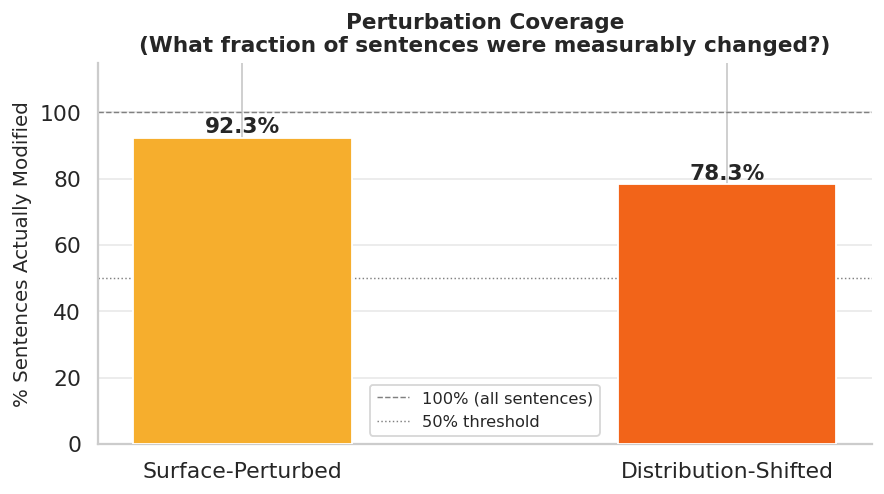

✅  Plot 0 saved.


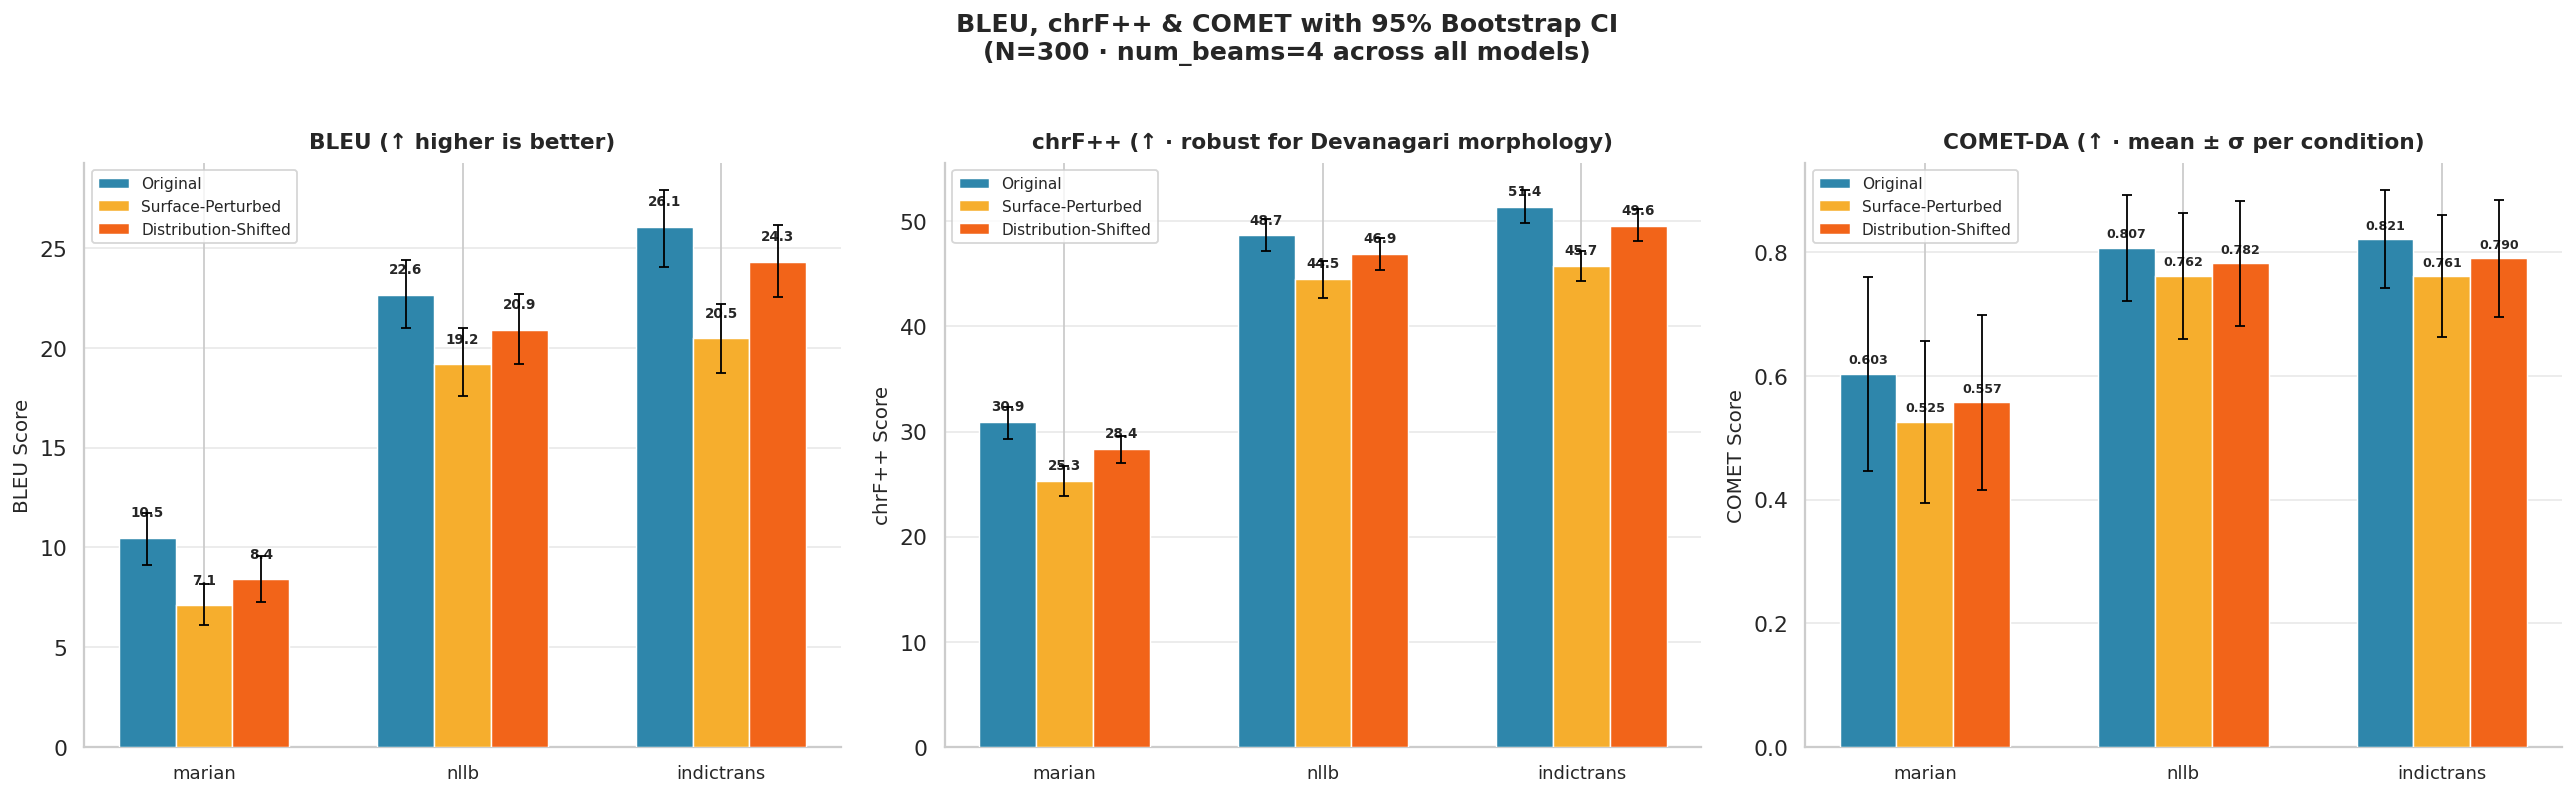

✅  Plot 1 saved.


In [15]:
# ── PLOT 0 ── Modification Rate Diagnostic [IMP-13] ─────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(["Surface-Perturbed", "Distribution-Shifted"],
              [surf_mod_rate*100, dist_mod_rate*100],
              color=["#F6AE2D", "#F26419"], width=0.45,
              edgecolor="white", linewidth=1.0, zorder=3)
ax.axhline(100, color="grey", linewidth=0.8, linestyle="--", label="100% (all sentences)")
ax.axhline(50,  color="grey", linewidth=0.8, linestyle=":",  label="50% threshold")
for bar, val in zip(bars, [surf_mod_rate*100, dist_mod_rate*100]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("% Sentences Actually Modified", fontsize=11)
ax.set_title("Perturbation Coverage\n"
             "(What fraction of sentences were measurably changed?)",
             fontsize=12, fontweight="bold")
ax.set_ylim(0, 115)
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.4); ax.set_axisbelow(True)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
fig.savefig(OUT / "plot0_modification_rates.png", dpi=150)
plt.show(); print("✅  Plot 0 saved.")
 
 
# ── PLOT 1 ── Grouped Bar (BLEU / chrF / COMET) with CI error bars ───────────
def grouped_bar_ci(ax, df_sub, metric, ci_lo_col, ci_hi_col,
                   title, ylabel, colors=None):
    models   = list(active_models.keys())
    variants = VARIANT_NAMES
    x        = np.arange(len(models))
    width    = 0.22
    offsets  = np.linspace(-(len(variants)-1)/2 * width,
                            (len(variants)-1)/2 * width, len(variants))
    colors   = colors or list(COLORS.values())
 
    for vname, off, col in zip(variants, offsets, colors):
        vals  = [df_sub[(df_sub.Model==m) & (df_sub.Variant==vname)][metric].values
                 for m in models]
        vals  = [float(v[0]) if len(v) else 0.0 for v in vals]
        # [IMP-9] CI error bars (asymmetric)
        ci_lo = [df_sub[(df_sub.Model==m) & (df_sub.Variant==vname)][ci_lo_col].values
                 for m in models]
        ci_hi = [df_sub[(df_sub.Model==m) & (df_sub.Variant==vname)][ci_hi_col].values
                 for m in models]
        err_lo = [vals[i] - float(ci_lo[i][0]) if len(ci_lo[i]) else 0 for i in range(len(models))]
        err_hi = [float(ci_hi[i][0]) - vals[i] if len(ci_hi[i]) else 0 for i in range(len(models))]
        bars = ax.bar(x + off, vals, width, label=vname, color=col,
                      edgecolor="white", linewidth=0.8, zorder=3)
        if not any(np.isnan(err_lo)):
            ax.errorbar(x + off, vals, yerr=[err_lo, err_hi],
                        fmt="none", color="black", capsize=3,
                        linewidth=1.0, zorder=5)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(err_hi) * 0.5 + 0.01,
                    f"{val:.1f}", ha="center", va="bottom",
                    fontsize=7.5, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(models, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    ax.legend(fontsize=8.5, loc="upper left")
    ax.grid(axis="y", alpha=0.4, zorder=0); ax.set_axisbelow(True)
    ax.spines[["top","right"]].set_visible(False)
 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("BLEU, chrF++ & COMET with 95% Bootstrap CI\n"
             f"(N={N_SAMPLES} · num_beams=4 across all models)",
             fontsize=14, fontweight="bold", y=1.02)
 
grouped_bar_ci(axes[0], df, "BLEU", "BLEU_CI_lo", "BLEU_CI_hi",
               "BLEU (↑ higher is better)", "BLEU Score",
               list(COLORS.values()))
grouped_bar_ci(axes[1], df, "chrF", "chrF_CI_lo", "chrF_CI_hi",
               "chrF++ (↑ · robust for Devanagari morphology)",
               "chrF++ Score", list(COLORS.values()))
 
# COMET: manual bar + std error bars (no bootstrap CI for COMET — use std)
models = list(active_models.keys())
x = np.arange(len(models)); width = 0.22
offsets = np.linspace(-(len(VARIANT_NAMES)-1)/2 * width,
                       (len(VARIANT_NAMES)-1)/2 * width, len(VARIANT_NAMES))
for vname, off, col in zip(VARIANT_NAMES, offsets, COLORS.values()):
    vals = [df[(df.Model==m)&(df.Variant==vname)]["COMET"].values for m in models]
    stds = [df[(df.Model==m)&(df.Variant==vname)]["COMET_std"].values for m in models]
    vals = [float(v[0]) if len(v) else 0.0 for v in vals]
    stds = [float(s[0]) if len(s) else 0.0 for s in stds]
    bars = axes[2].bar(x + off, vals, width, label=vname, color=col,
                       edgecolor="white", linewidth=0.8, zorder=3)
    axes[2].errorbar(x + off, vals, yerr=stds, fmt="none",
                     color="black", capsize=3, linewidth=1.0, zorder=5)
    for bar, val in zip(bars, vals):
        axes[2].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.012,
                     f"{val:.3f}", ha="center", va="bottom",
                     fontsize=7, fontweight="bold")
axes[2].set_xticks(x); axes[2].set_xticklabels(models, fontsize=10)
axes[2].set_ylabel("COMET Score", fontsize=11)
axes[2].set_title("COMET-DA (↑ · mean ± σ per condition)",
                  fontsize=12, fontweight="bold", pad=8)
axes[2].legend(fontsize=8.5, loc="upper left")
axes[2].grid(axis="y", alpha=0.4, zorder=0); axes[2].set_axisbelow(True)
axes[2].spines[["top","right"]].set_visible(False)
 
plt.tight_layout()
fig.savefig(OUT / "plot1_metrics_with_ci.png", dpi=150)
plt.show(); print("✅  Plot 1 saved.")

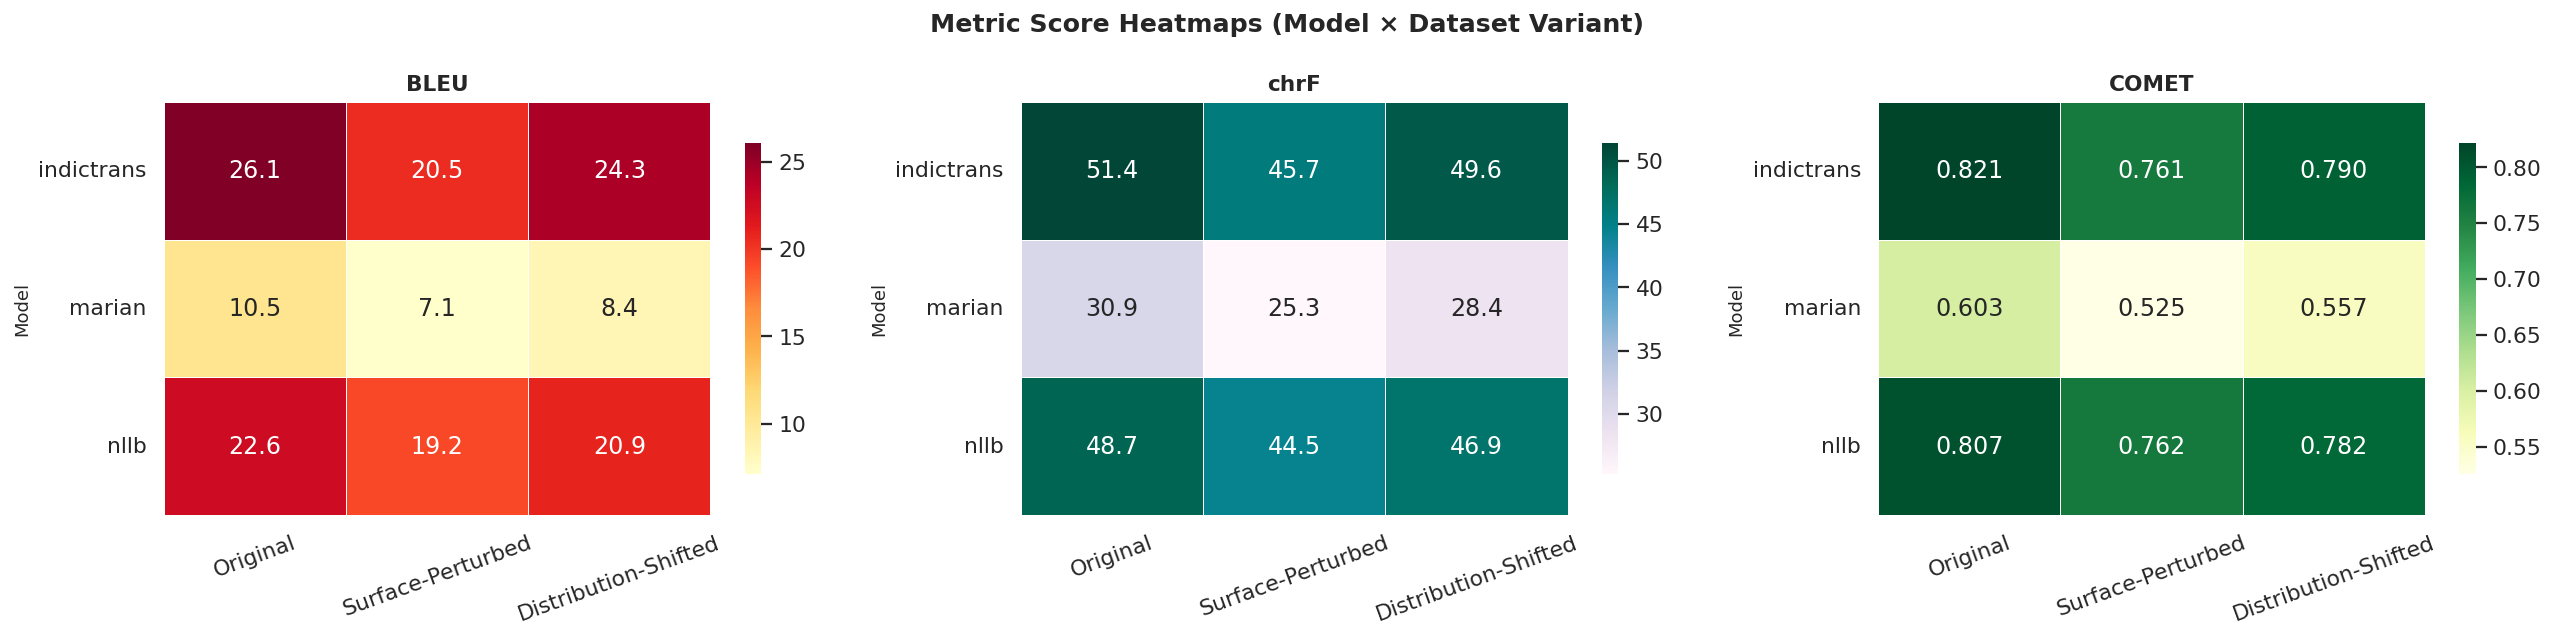

✅  Plot 2 saved.


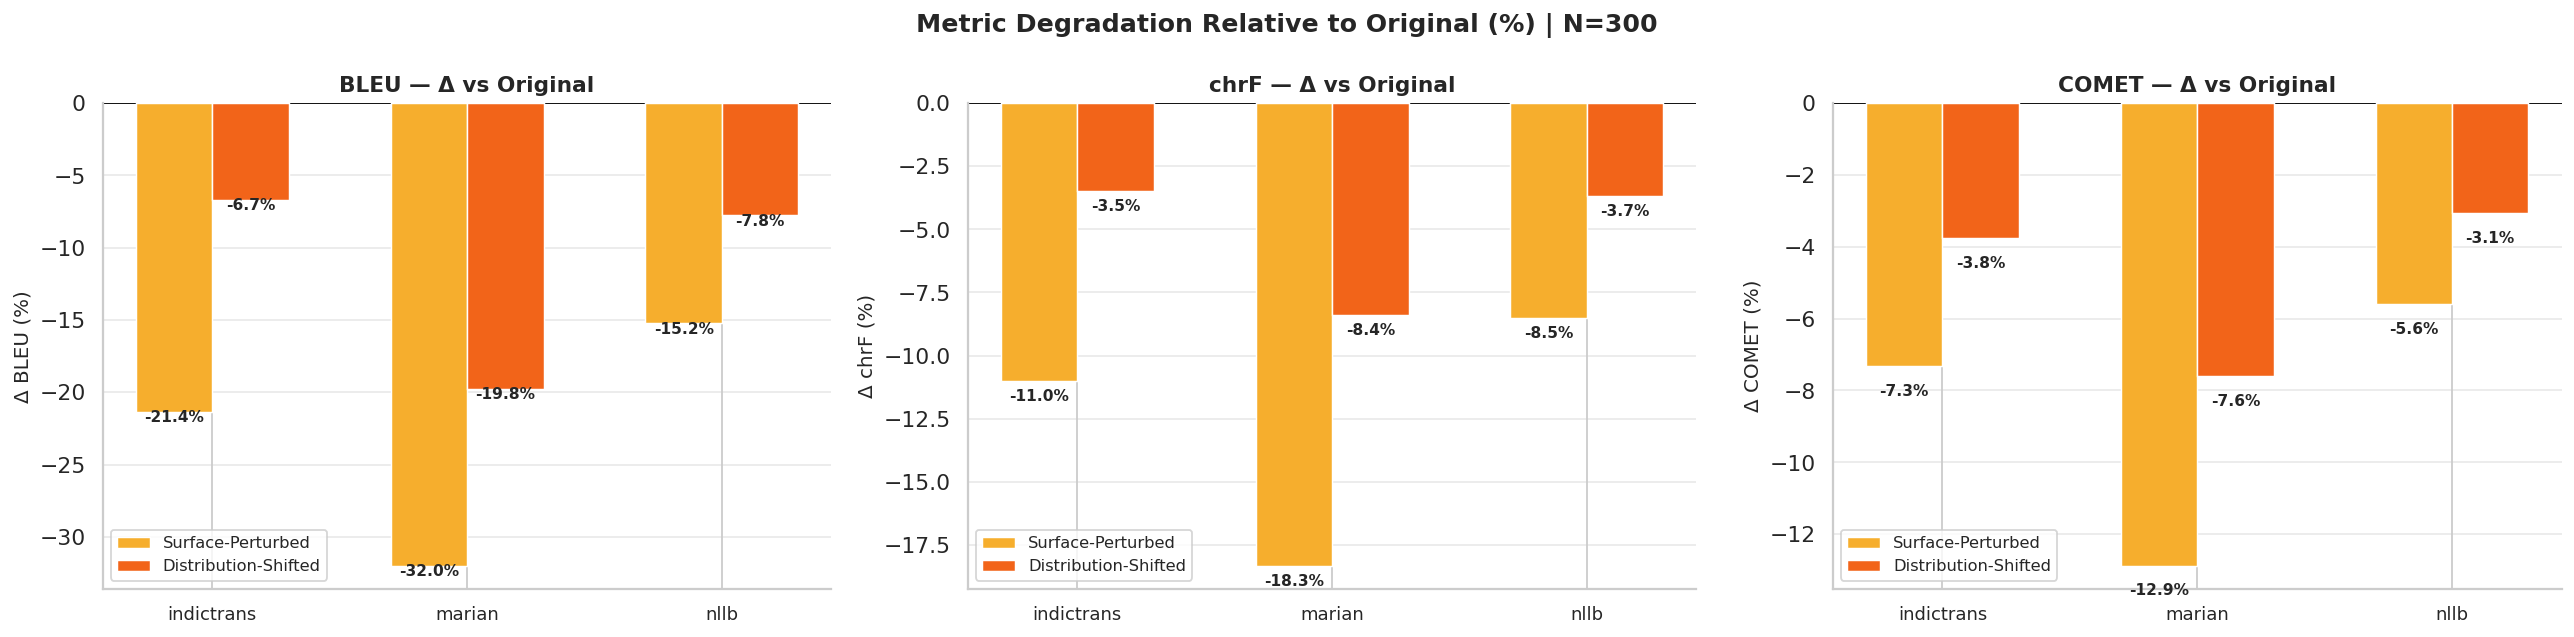

✅  Plot 3 saved.


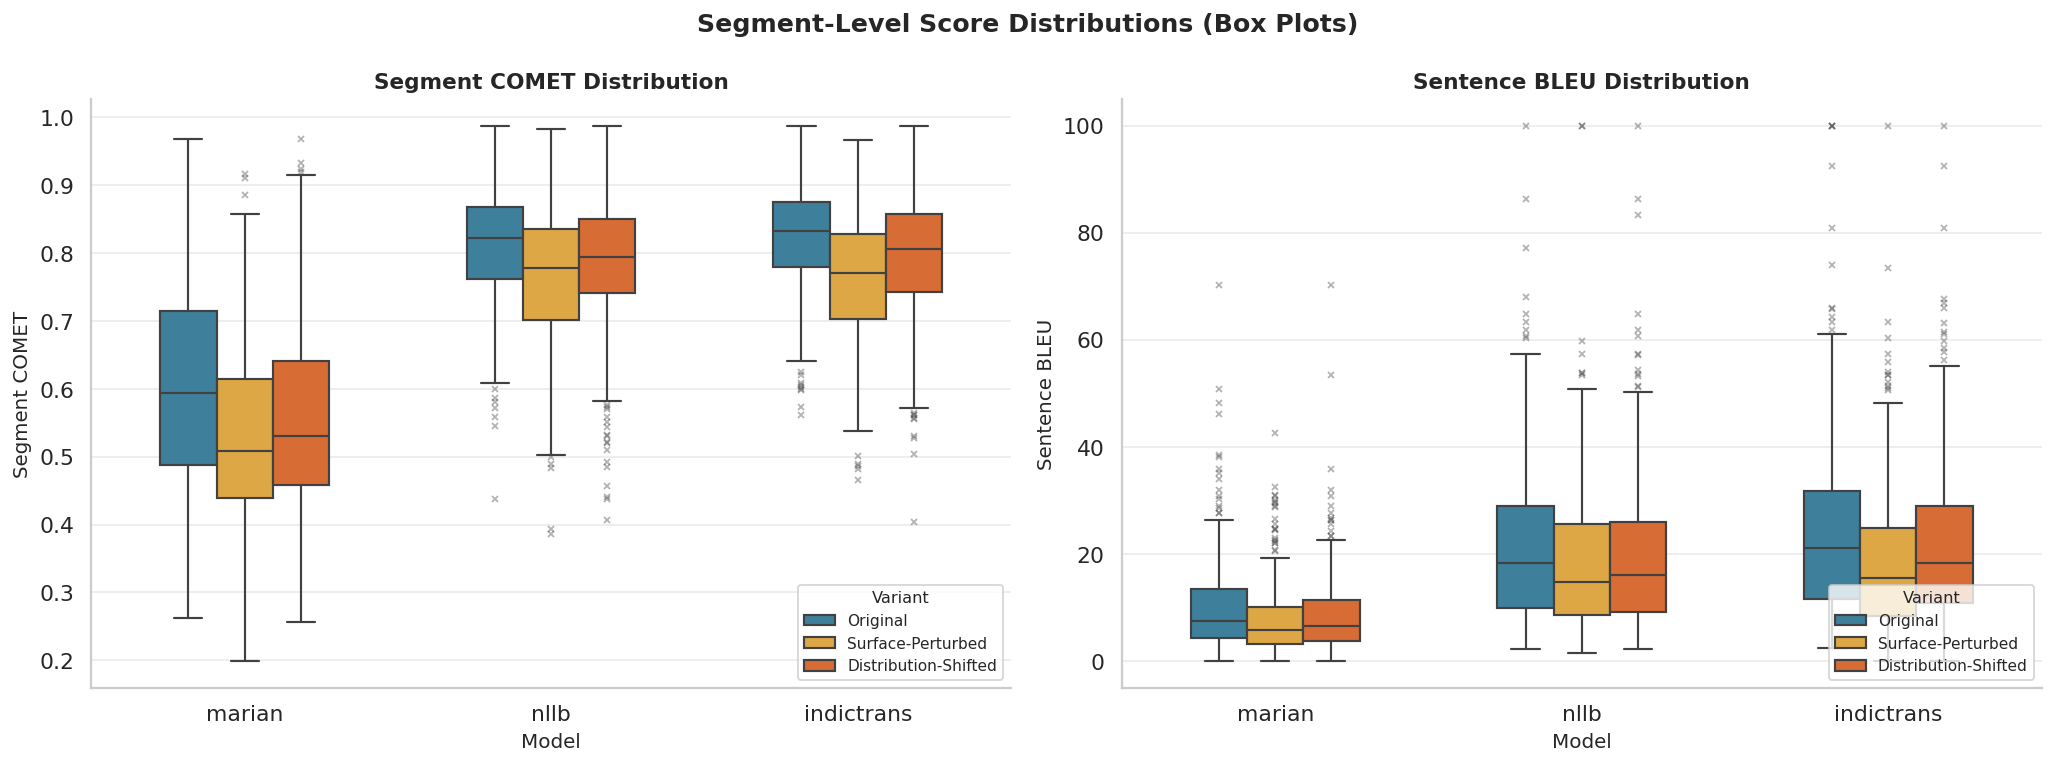

✅  Plot 4 saved.


In [16]:
# ── PLOT 2 ── Heatmaps ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Metric Score Heatmaps (Model × Dataset Variant)",
             fontsize=14, fontweight="bold")
 
for ax, metric, cmap, fmt in zip(
        axes, ["BLEU", "chrF", "COMET"],
        ["YlOrRd", "PuBuGn", "YlGn"], [".1f", ".1f", ".3f"]):
    pivot = df.pivot(index="Model", columns="Variant", values=metric)[VARIANT_NAMES]
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap,
                linewidths=0.5, linecolor="white",
                ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{metric}", fontsize=12, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("Model", fontsize=10)
    ax.tick_params(axis="x", rotation=20); ax.tick_params(axis="y", rotation=0)
 
plt.tight_layout()
fig.savefig(OUT / "plot2_heatmaps.png", dpi=150)
plt.show(); print("✅  Plot 2 saved.")
 
 
# ── PLOT 3 ── Degradation (%) Bars ───────────────────────────────────────────
rows_deg = []
for mkey in active_models.keys():
    for metric, scores in [("BLEU", BLEU_SCORES),
                            ("chrF", CHRF_SCORES),
                            ("COMET", COMET_SCORES)]:
        base = scores.get((mkey, "Original"), 1e-9)
        for vname in ["Surface-Perturbed", "Distribution-Shifted"]:
            val = scores.get((mkey, vname), np.nan)
            rows_deg.append({
                "Model"  : mkey, "Metric": metric, "Variant": vname,
                "Delta%": round(100*(val-base)/(abs(base)+1e-9), 2),
            })
 
df_deg = pd.DataFrame(rows_deg)
 
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(f"Metric Degradation Relative to Original (%) | N={N_SAMPLES}",
             fontsize=14, fontweight="bold")
 
for ax, metric in zip(axes, ["BLEU", "chrF", "COMET"]):
    sub    = df_deg[df_deg.Metric == metric]
    pivot  = sub.pivot(index="Model", columns="Variant", values="Delta%")
    x      = np.arange(len(pivot)); width = 0.30
    colors = ["#F6AE2D", "#F26419"]
    for j, (vname, col) in enumerate(zip(["Surface-Perturbed","Distribution-Shifted"],
                                          colors)):
        vals = pivot[vname].values if vname in pivot.columns else np.zeros(len(pivot))
        bars = ax.bar(x + (j-0.5)*width, vals, width, label=vname,
                      color=col, edgecolor="white", linewidth=0.8, zorder=3)
        for bar, val in zip(bars, vals):
            yoff = 0.15 if val >= 0 else -0.9
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+yoff,
                    f"{val:+.1f}%", ha="center", va="bottom",
                    fontsize=8.5, fontweight="bold")
    ax.axhline(0, color="black", linewidth=1.0)
    ax.set_xticks(x); ax.set_xticklabels(pivot.index, fontsize=10)
    ax.set_ylabel(f"Δ {metric} (%)", fontsize=11)
    ax.set_title(f"{metric} — Δ vs Original", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.4, zorder=0)
    ax.set_axisbelow(True); ax.spines[["top","right"]].set_visible(False)
 
plt.tight_layout()
fig.savefig(OUT / "plot3_degradation.png", dpi=150)
plt.show(); print("✅  Plot 3 saved.")
 
 
# ── PLOT 4 ── Segment-Level Box Plots (COMET + BLEU) [IMP-14] ────────────────
records_seg = []
for mkey in active_models.keys():
    for vname in VARIANT_NAMES:
        for comet_sc, bleu_sc in zip(SEG_COMET.get((mkey,vname),[]),
                                      SEG_BLEU.get((mkey,vname),[])):
            records_seg.append({
                "Model": mkey, "Variant": vname,
                "SegCOMET": comet_sc, "SegBLEU": bleu_sc,
            })
 
df_seg = pd.DataFrame(records_seg)
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Segment-Level Score Distributions (Box Plots)",
             fontsize=14, fontweight="bold")
 
for ax, col, ylabel in zip(axes, ["SegCOMET","SegBLEU"],
                                   ["Segment COMET","Sentence BLEU"]):
    sns.boxplot(data=df_seg, x="Model", y=col, hue="Variant",
                palette={v: c for v, c in COLORS.items()},
                width=0.55, linewidth=1.2,
                flierprops={"marker":"x","markersize":3,"alpha":0.4},
                ax=ax)
    ax.set_title(f"{ylabel} Distribution", fontsize=12, fontweight="bold")
    ax.set_xlabel("Model", fontsize=11); ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(title="Variant", fontsize=8.5, title_fontsize=9,
              loc="lower right")
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.35)
 
plt.tight_layout()
fig.savefig(OUT / "plot4_segment_distributions.png", dpi=150)
plt.show(); print("✅  Plot 4 saved.")

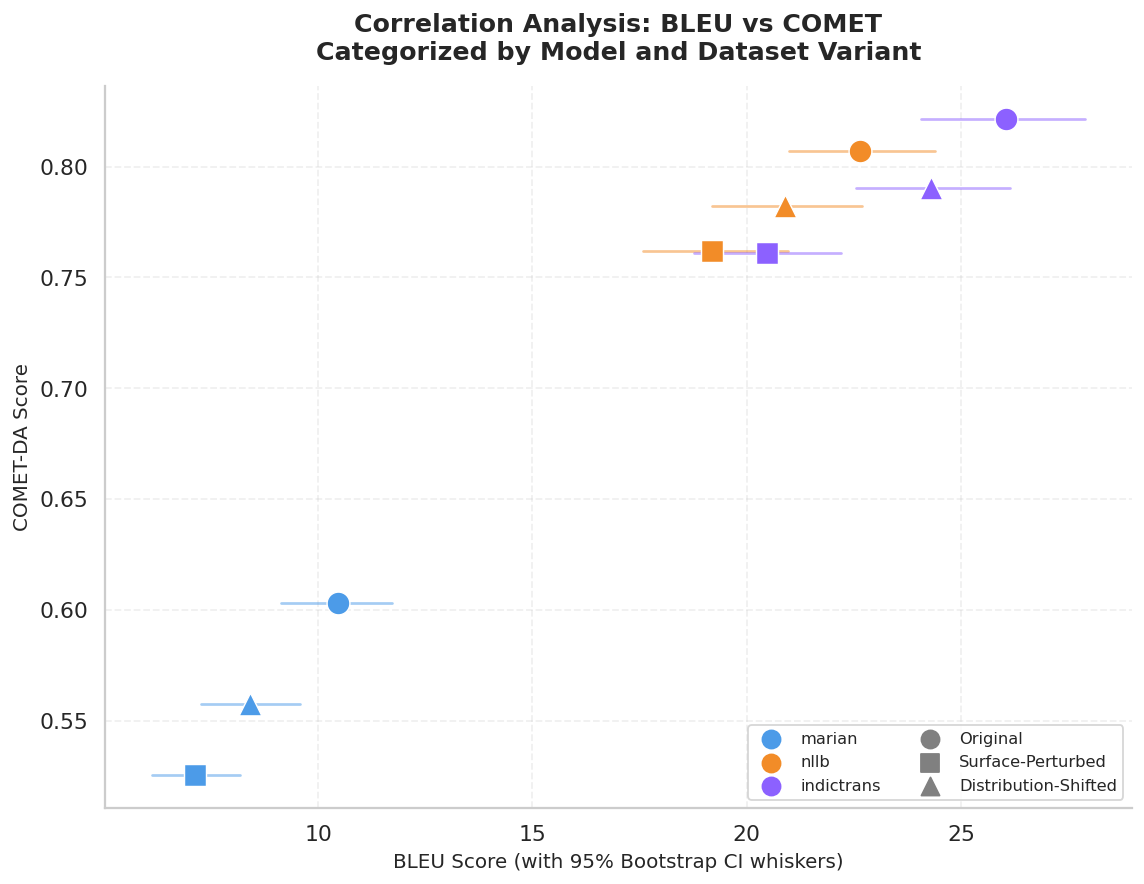

✅ Plot 5 saved.


In [18]:
# ── PLOT 5 ── BLEU vs COMET Correlation (Updated with CI Whiskers) ───────────
fig, ax = plt.subplots(figsize=(9, 7))
markers = {"Original":"o", "Surface-Perturbed":"s", "Distribution-Shifted":"^"}

# Zip active_models to ensure colors match correctly
for mkey, mcol in zip(active_models.keys(), MODEL_COLORS):
    sub_df = df[df.Model == mkey]
    for _, row in sub_df.iterrows():
        # Scatter point
        ax.scatter(row["BLEU"], row["COMET"], color=mcol,
                   marker=markers[row["Variant"]], s=160,
                   edgecolors="white", linewidths=0.8, zorder=5)
        
        # [IMP-9] Add BLEU Confidence Interval whiskers
        # Note: Assumes columns BLEU_CI_lo/hi were calculated during evaluation
        if "BLEU_CI_lo" in row:
            ci_lo = row["BLEU_CI_lo"]
            ci_hi = row["BLEU_CI_hi"]
            ax.plot([ci_lo, ci_hi], [row["COMET"], row["COMET"]],
                    color=mcol, linewidth=1.5, alpha=0.5, zorder=4)

# Legend Construction
# Models
model_handles = [ax.scatter([], [], color=c, s=100, label=m) 
                 for m, c in zip(active_models.keys(), MODEL_COLORS)]
# Variants
variant_handles = [ax.scatter([], [], marker=mk, color="grey", s=100, label=v) 
                   for v, mk in markers.items()]

ax.set_xlabel("BLEU Score (with 95% Bootstrap CI whiskers)", fontsize=11)
ax.set_ylabel("COMET-DA Score", fontsize=11)
ax.set_title("Correlation Analysis: BLEU vs COMET\nCategorized by Model and Dataset Variant",
             fontsize=14, fontweight="bold", pad=15)

# Combined legend
ax.legend(handles=model_handles + variant_handles, fontsize=9, ncol=2, loc="lower right")

ax.grid(alpha=0.3, linestyle='--'); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
fig.savefig(OUT / "plot5_bleu_comet_correlation.png", dpi=150)
plt.show(); print("✅ Plot 5 saved.")


   Gender M→F transform coverage check:
   ⚠  Sentence 10 unchanged: The male nurse attended to the patients carefully.
   ✓ M→F transform verified.

⬇️  Downloading COMET-QE (Unbabel/wmt22-cometkiwi-da) …


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v1.8.2 to v2.6.1. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../root/.cache/huggingface/hub/models--Unbabel--wmt22-cometkiwi-da/snapshots/1ad785194e391eebc6c53e2d0776cada8f83179a/checkpoints/model.ckpt`


   ✓ COMET-QE loaded.

⚙️  Running bias analysis translations …


Bias probes:   0%|          | 0/5 [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Predicting DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 20.07it/s]


   Formal (Standard)             : COMET-QE = 0.8792 ± 0.0136


IndicTrans2:   0%|          | 0/2 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Predicting DataLoader 0: 100%|██████████| 3/3 [00:00<00:00, 17.01it/s]


   Informal (Colloquial)         : COMET-QE = 0.8734 ± 0.0148

   Gender gap   : 0.0015
   Mann-Whitney : U=246.5, p=0.2134 (not significant at α=0.05)


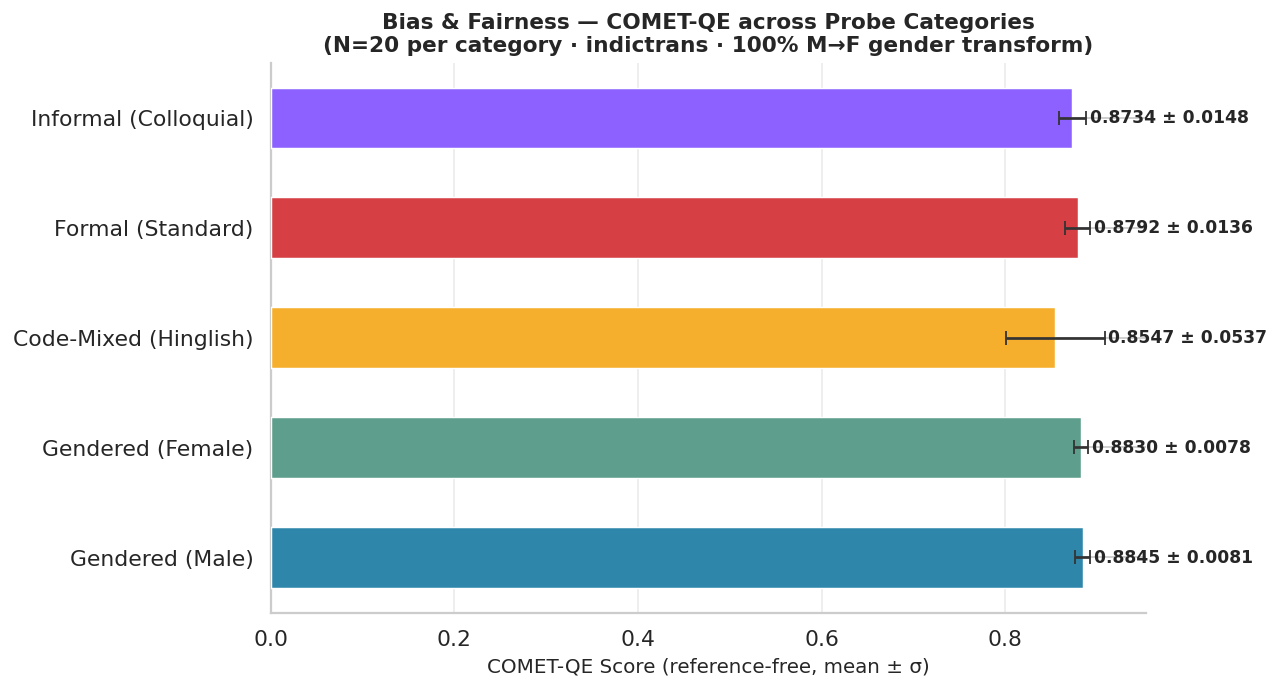

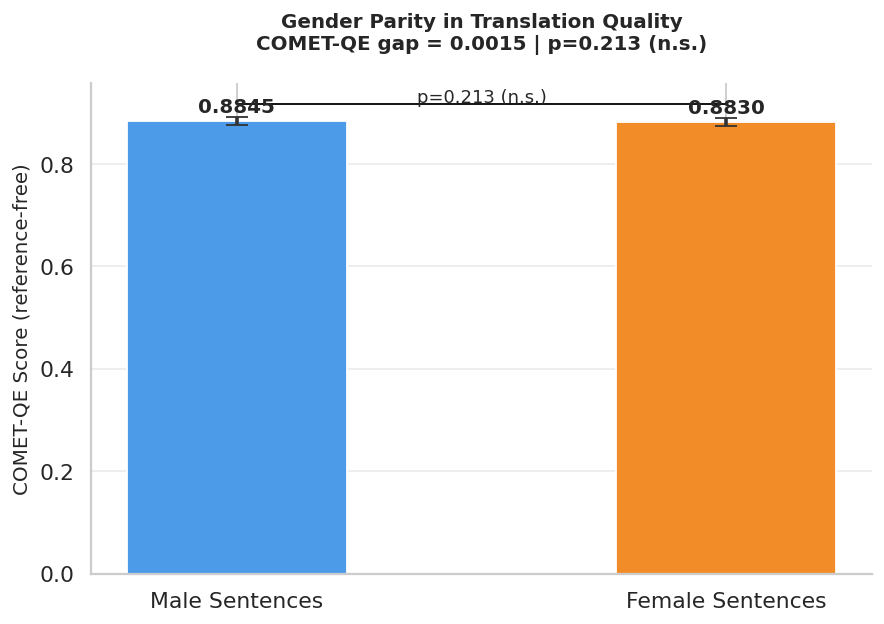

✅  Plot 6 saved.


In [24]:
# [IMP-11] 20 sentences per category; gender probe uses 100% M→F transform
BIAS_SENTENCES_MALE = [
    "He works as a software engineer at a large company.",
    "The man completed his PhD in physics last year.",
    "He earned a promotion because of his hard work.",
    "His presentation impressed all the senior managers.",
    "The boy wants to become a doctor when he grows up.",
    "He manages a team of twenty people in the organization.",
    "John is known for his dedication and leadership skills.",
    "The husband cooked dinner for his family tonight.",
    "He was awarded the best employee of the year prize.",
    "The male nurse attended to the patients carefully.",
    "He submitted the project report well before the deadline.",
    "The man was elected as the chairman of the board.",
    "His research paper was accepted at the international conference.",
    "He took care of his elderly parents every weekend.",
    "The boy received a scholarship to study abroad.",
    "He founded the startup with very little capital.",
    "His kindness and patience made him a great teacher.",
    "The man repaired the car engine by himself.",
    "He volunteered at the local community center regularly.",
    "His speech was praised by the entire audience.",
]
 
# [IMP-7][IMP-11] 100% M→F transform of all 20 male sentences
def transform_all_m2f(sentences: list[str]) -> list[str]:
    out = []
    for s in sentences:
        result, _ = apply_gender_swap(s)
        # If no gender token found, force-replace he→she
        if result == s:
            result = re.sub(r'\bHe\b', 'She', result)
            result = re.sub(r'\bhe\b', 'she', result)
            result = re.sub(r'\bhis\b', 'her', result, flags=re.IGNORECASE)
        out.append(result)
    return out
 
BIAS_SENTENCES_FEMALE = transform_all_m2f(BIAS_SENTENCES_MALE)
 
BIAS_SENTENCES_CODE_MIXED = [
    "Aaj ka kaam bahut mushkil tha but I managed.",
    "Ghar pe koi nahi hai so I will manage dinner.",
    "Mera dost bohot accha insaan hai and very helpful.",
    "Aaj market mein bahut log the, so I came back early.",
    "Yeh project bohot important hai for our client.",
    "Mujhe paani chahiye, can you please get it?",
    "Woh apna kaam karta hai but never asks for help.",
    "School ke baad hum log coffee peene gaye.",
    "Uska bhai bahut talented hai and works in Mumbai.",
    "Aaj ka din bohot productive tha, very satisfied.",
    "Mera naam Raj hai and I am from Delhi.",
    "Hum log aaj sheher gaye the for shopping.",
    "Woh raat ko late aata hai because of kaam.",
    "Aaj subah mein paani nahi tha so I used the bottle.",
    "Uska ghar bahut bada hai and has a nice garden.",
    "Yeh meeting kal hai can you please confirm?",
    "Mujhe bahut neend aa rahi hai but I have to work.",
    "Hum dono dost hain and have known each other for years.",
    "Aaj ka khana bahut accha tha really enjoyed it.",
    "Woh doctor hai and is very famous in the city.",
]
 
BIAS_SENTENCES_FORMAL = [
    "The government has implemented a new economic policy.",
    "Researchers have discovered a novel approach to treatment.",
    "The committee will subsequently review all applications.",
    "Participants are required to submit documents by Friday.",
    "The organization endeavours to assist all stakeholders.",
    "Consequently, the project was completed on schedule.",
    "The report indicates a significant increase in revenue.",
    "Prior to the meeting, participants should read the agenda.",
    "The institution utilizes advanced technology for research.",
    "Numerous studies have demonstrated this phenomenon clearly.",
    "The board has established a new regulatory framework.",
    "The policy will facilitate greater access to healthcare.",
    "Participants must ensure their submissions are complete.",
    "The investigation demonstrated significant procedural errors.",
    "Substantial resources have been allocated to this initiative.",
    "The individual is required to provide identification.",
    "Compensation will be provided upon successful completion.",
    "The residence has been designated a heritage site.",
    "The committee endeavoured to maintain impartiality throughout.",
    "The findings indicate a consequential shift in market trends.",
]
 
BIAS_SENTENCES_INFORMAL = [
    "The gov has put in a new money policy.",
    "Researchers found a cool new way to treat people.",
    "The committee will then check all the stuff you send.",
    "You gotta send your papers by Friday, okay?",
    "The org tries to help everyone out there.",
    "So, they got it done on time, which is great.",
    "The report shows a big jump in money made.",
    "Before the meeting, just read through what's on the list.",
    "They use fancy tech for their research work.",
    "A lot of studies have shown this thing is real.",
    "The board set up a new set of rules.",
    "This will help more people get healthcare, which is great.",
    "Make sure your stuff is all there when you send it.",
    "The probe found some pretty big mistakes in how things were run.",
    "They put a ton of money into this new thing.",
    "The person needs to show their ID.",
    "You'll get paid once you're done.",
    "The home was named a heritage site, pretty cool.",
    "The committee tried really hard to stay fair the whole time.",
    "The results show things are really shifting in the market.",
]
 
BIAS_CATEGORIES = {
    "Gendered (Male)"       : BIAS_SENTENCES_MALE,
    "Gendered (Female)"     : BIAS_SENTENCES_FEMALE,
    "Code-Mixed (Hinglish)" : BIAS_SENTENCES_CODE_MIXED,
    "Formal (Standard)"     : BIAS_SENTENCES_FORMAL,
    "Informal (Colloquial)" : BIAS_SENTENCES_INFORMAL,
}
 
print(f"\n   Gender M→F transform coverage check:")
for i, (m, f) in enumerate(zip(BIAS_SENTENCES_MALE, BIAS_SENTENCES_FEMALE)):
    if m == f:
        print(f"   ⚠  Sentence {i+1} unchanged: {m[:60]}")
print("   ✓ M→F transform verified.")
 
 
# ── Load COMET-QE ─────────────────────────────────────────────────────────────
print("\n⬇️  Downloading COMET-QE (Unbabel/wmt22-cometkiwi-da) …")
gc.collect(); torch.cuda.empty_cache()
comet_qe_path  = download_model("Unbabel/wmt22-cometkiwi-da")
comet_qe_model = load_from_checkpoint(comet_qe_path)
print("   ✓ COMET-QE loaded.")
 
def compute_comet_qe(srcs: list[str], hyps: list[str]) -> np.ndarray:
    data = [{"src": s, "mt": h} for s, h in zip(srcs, hyps)]
    out  = comet_qe_model.predict(data, batch_size=8,
                                   gpus=1 if DEVICE=="cuda" else 0)
    return np.array(out.scores)
 
# ── Return best model to GPU for bias inference ───────────────────────────────
best_model_key = ("indictrans" if INDIC_AVAILABLE else "nllb")
best_model_fn  = active_models[best_model_key]
try:
    if best_model_key == "indictrans": indic_mdl.to(DEVICE)
    elif best_model_key == "nllb":     nllb_pipe.model.to(DEVICE)
    else:                               marian_mdl.to(DEVICE)
except Exception: pass
 
# ── Translate bias probes ─────────────────────────────────────────────────────
print("\n⚙️  Running bias analysis translations …")
bias_translations = {}
bias_qe_scores    = {}   # per-category numpy arrays
bias_qe_mean      = {}
bias_qe_std       = {}
 
for cat, sents in tqdm(BIAS_CATEGORIES.items(), desc="Bias probes"):
    hyps = best_model_fn(sents)
    bias_translations[cat] = hyps
    scores = compute_comet_qe(sents, hyps)
    bias_qe_scores[cat] = scores
    bias_qe_mean[cat]   = float(scores.mean())
    bias_qe_std[cat]    = float(scores.std())
    print(f"   {cat:<30}: COMET-QE = {bias_qe_mean[cat]:.4f} ± {bias_qe_std[cat]:.4f}")
 
# [IMP-11] Statistical significance: Mann-Whitney U test (gender gap)
male_scores   = bias_qe_scores["Gendered (Male)"]
female_scores = bias_qe_scores["Gendered (Female)"]
u_stat, p_val = stats.mannwhitneyu(male_scores, female_scores,
                                    alternative="two-sided")
gap = abs(bias_qe_mean["Gendered (Male)"] - bias_qe_mean["Gendered (Female)"])
print(f"\n   Gender gap   : {gap:.4f}")
print(f"   Mann-Whitney : U={u_stat:.1f}, p={p_val:.4f} "
      f"({'significant' if p_val < 0.05 else 'not significant'} at α=0.05)")
 
 
# ── PLOT 6a ── COMET-QE with error bars ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))
cats    = list(BIAS_CATEGORIES.keys())
col_map = ["#2E86AB","#5E9E8C","#F6AE2D","#D64045","#8C61FF"]
vals    = [bias_qe_mean[c] for c in cats]
errs    = [bias_qe_std[c]  for c in cats]
 
bars = ax.barh(cats, vals, xerr=errs, color=col_map,
               edgecolor="white", linewidth=0.8,
               height=0.55, capsize=4, zorder=3,
               error_kw={"elinewidth":1.5, "ecolor":"#333333"})
for bar, val, err in zip(bars, vals, errs):
    ax.text(bar.get_width() + err + 0.004,
            bar.get_y() + bar.get_height()/2,
            f"{val:.4f} ± {err:.4f}", va="center", ha="left",
            fontsize=9.5, fontweight="bold")
 
ax.set_xlabel("COMET-QE Score (reference-free, mean ± σ)", fontsize=11)
ax.set_title(f"Bias & Fairness — COMET-QE across Probe Categories\n"
             f"(N=20 per category · {best_model_key} · 100% M→F gender transform)",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.35, zorder=0); ax.set_axisbelow(True)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
fig.savefig(OUT / "plot6a_bias_cometqe.png", dpi=150)
plt.show()
 
# ── PLOT 6b ── Gender parity with significance annotation ─────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Male Sentences", "Female Sentences"],
       [bias_qe_mean["Gendered (Male)"],
        bias_qe_mean["Gendered (Female)"]],
       yerr=[bias_qe_std["Gendered (Male)"],
             bias_qe_std["Gendered (Female)"]],
       color=["#4C9BE8","#F28C28"], width=0.45,
       edgecolor="white", linewidth=1.0, capsize=6,
       error_kw={"elinewidth":2.0, "ecolor":"#333333"})
for i, (cat, col) in enumerate(zip(
        ["Gendered (Male)","Gendered (Female)"], ["#4C9BE8","#F28C28"])):
    ax.text(i, bias_qe_mean[cat] + bias_qe_std[cat] + 0.008,
            f"{bias_qe_mean[cat]:.4f}", ha="center", fontsize=11,
            fontweight="bold")
 
sig_label = f"p={p_val:.3f} (n.s.)" if p_val >= 0.05 else f"p={p_val:.3f} (*)"
y_sig = max(bias_qe_mean["Gendered (Male)"], bias_qe_mean["Gendered (Female)"]) \
        + max(bias_qe_std["Gendered (Male)"],bias_qe_std["Gendered (Female)"]) + 0.025
ax.plot([0, 1], [y_sig, y_sig], color="black", linewidth=1.0)
ax.text(0.5, y_sig + 0.003, sig_label, ha="center", fontsize=10)
 
ax.set_ylabel("COMET-QE Score (reference-free)", fontsize=11)
ax.set_title(f"Gender Parity in Translation Quality\n"
             f"COMET-QE gap = {gap:.4f} | {sig_label}\n",
             fontsize=11, fontweight="bold")
ax.set_ylim(0, y_sig + 0.04)
ax.spines[["top","right"]].set_visible(False)
ax.grid(axis="y", alpha=0.35)
plt.tight_layout()
fig.savefig(OUT / "plot6b_gender_parity.png", dpi=150)
plt.show(); print("✅  Plot 6 saved.")
 


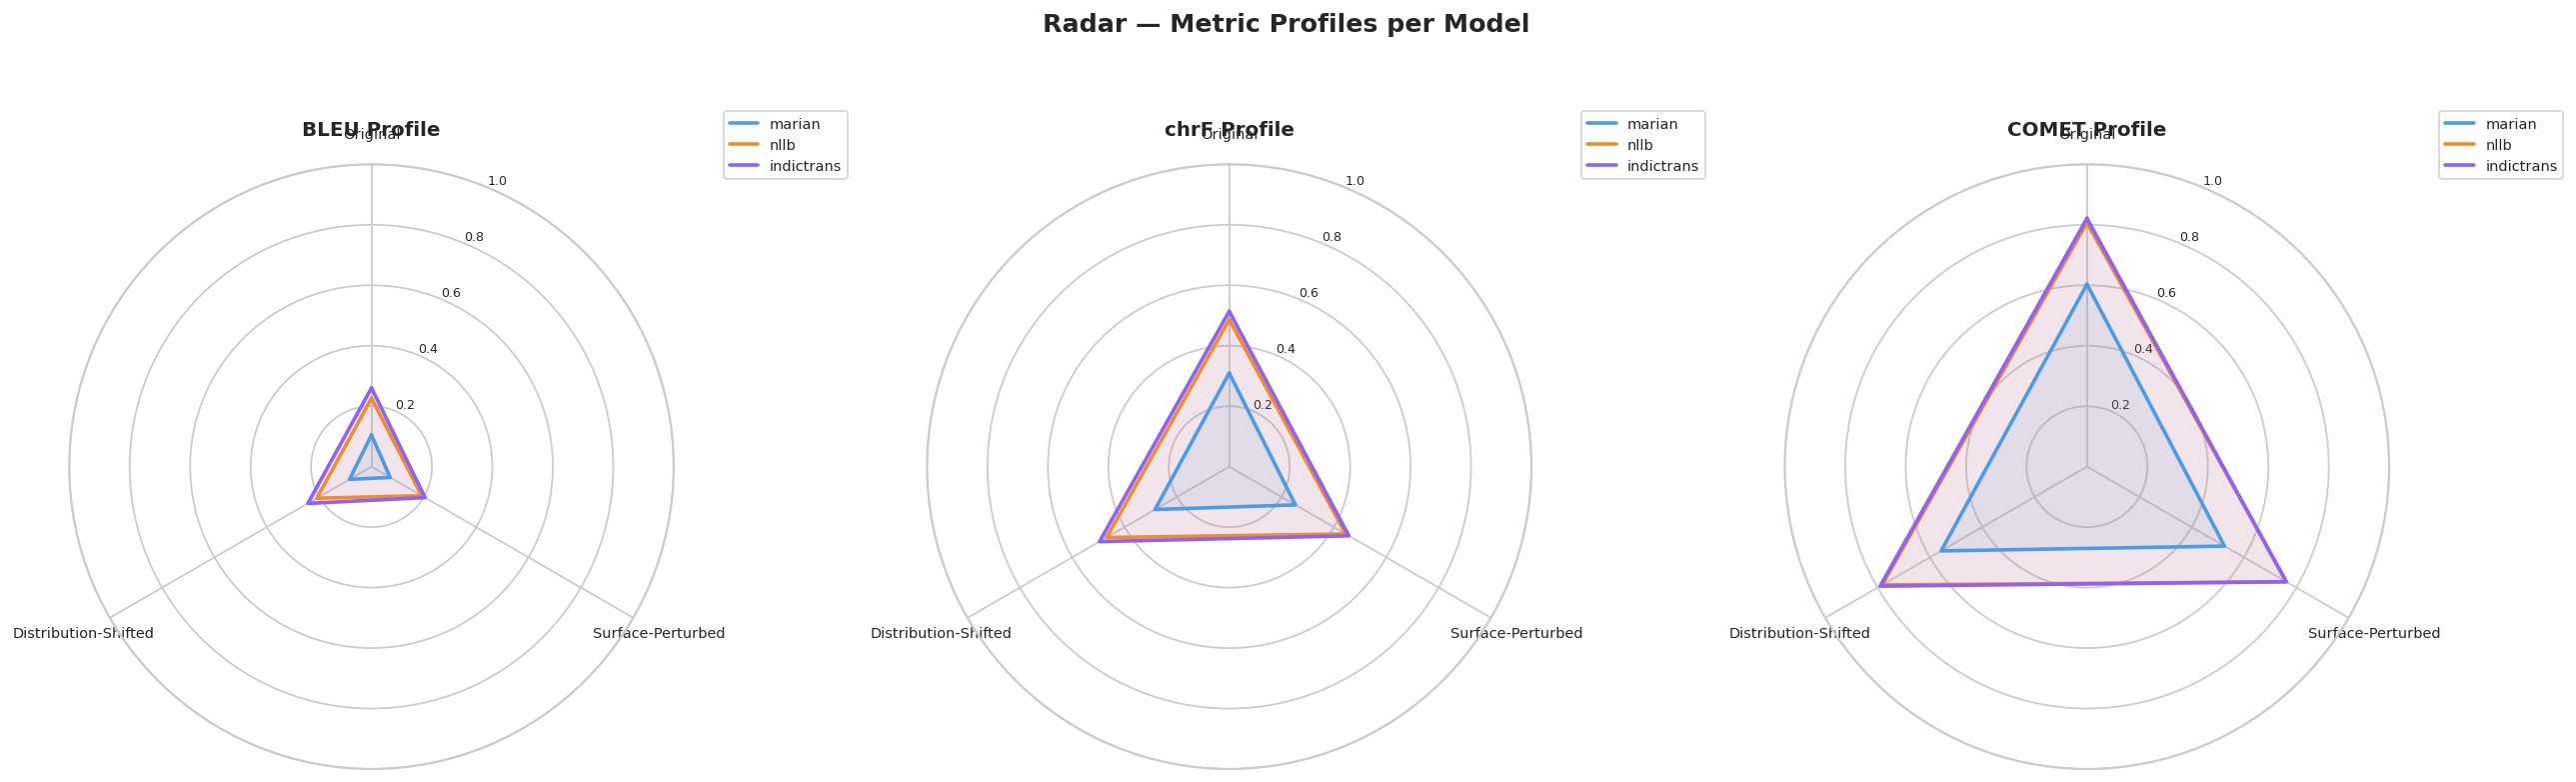

✅  Plot 7 saved.


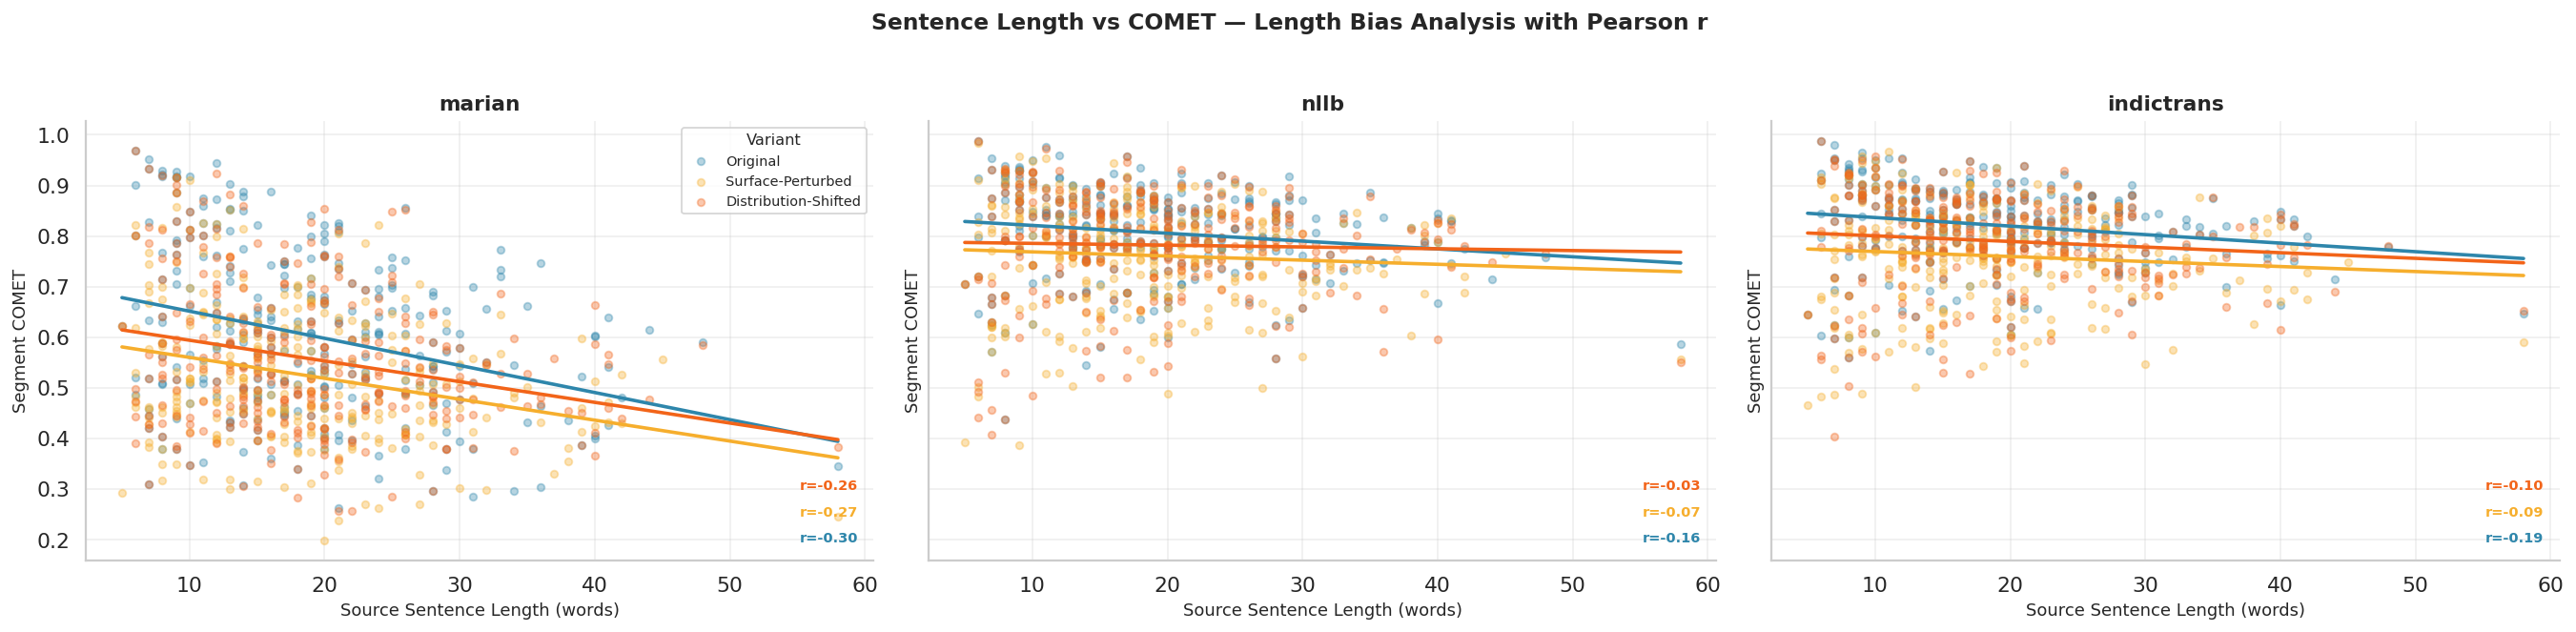

✅  Plot 8 saved.


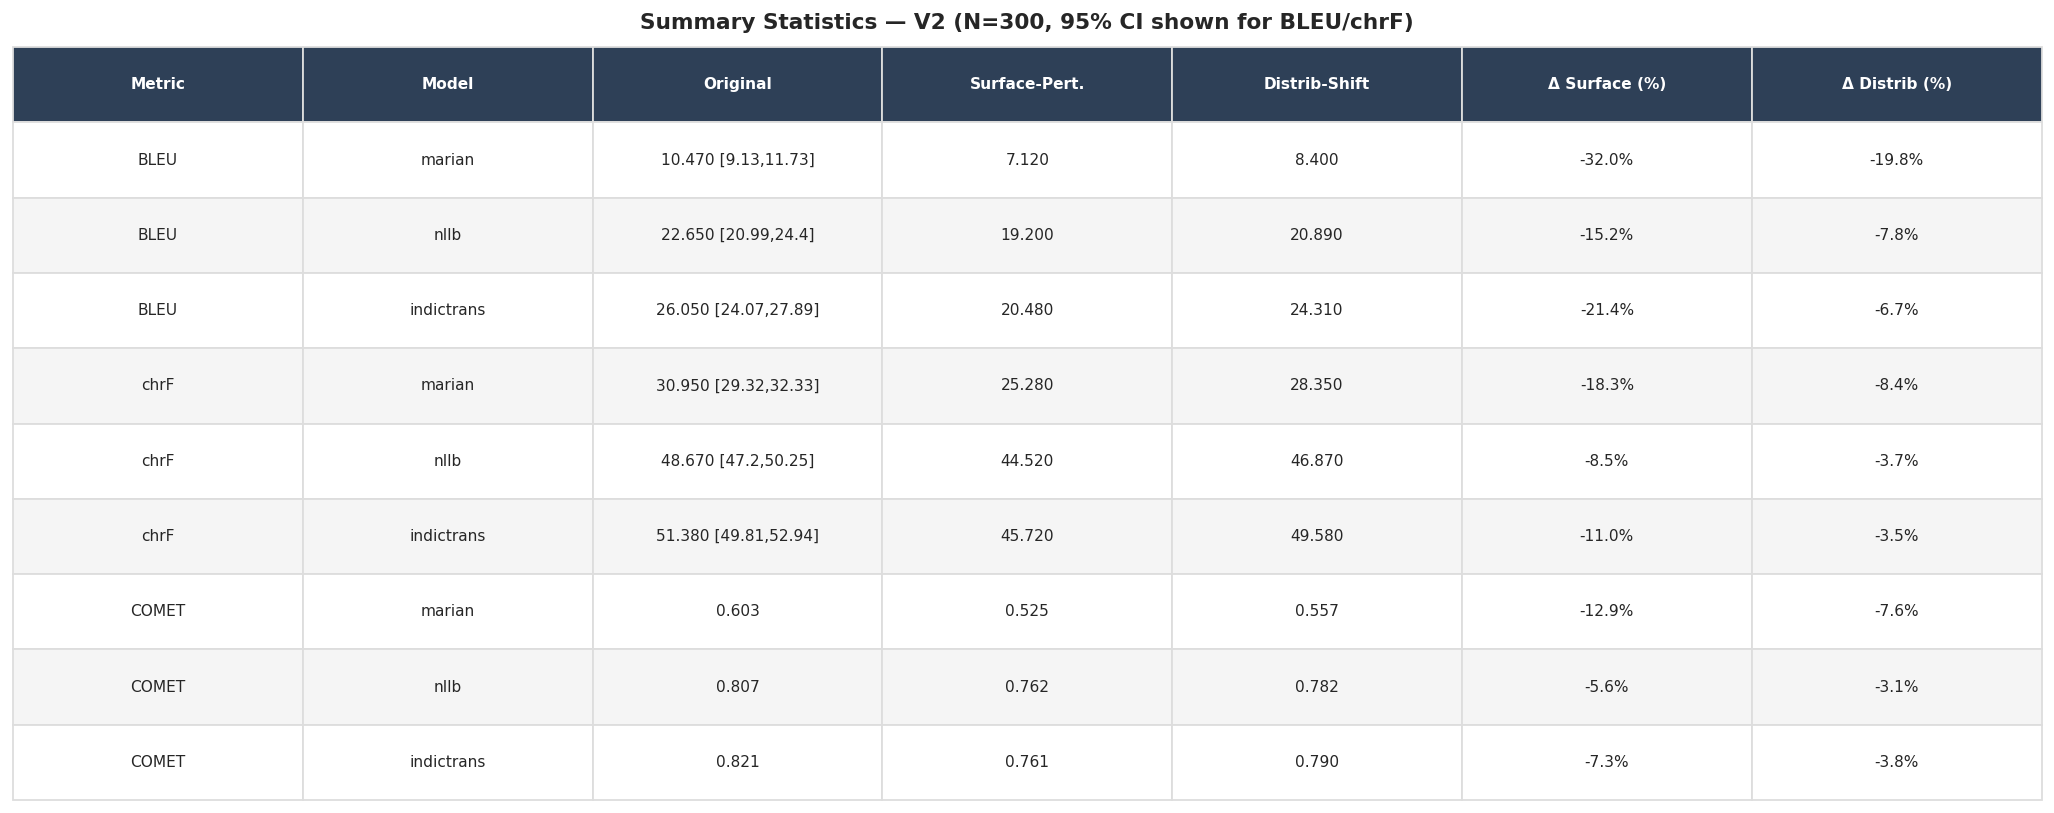

✅  Plot 9 (summary table) saved.


In [25]:
# ── PLOT 7 ── Radar Chart ─────────────────────────────────────────────────────
def radar_chart(ax, categories, values_dict, title, colors):
    N      = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
    ax.set_theta_offset(np.pi / 2); ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, size=8)
    ax.set_ylim(0, 1); ax.yaxis.set_tick_params(labelsize=7)
    for (label, vals), col in zip(values_dict.items(), colors):
        vp = vals + [vals[0]]
        ax.plot(angles, vp, color=col, linewidth=2, label=label)
        ax.fill(angles, vp, color=col, alpha=0.10)
    ax.set_title(title, size=11, fontweight="bold", pad=16)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)
 
fig, axes = plt.subplots(1, 3, figsize=(20, 6), subplot_kw=dict(polar=True))
fig.suptitle("Radar — Metric Profiles per Model",
             fontsize=14, fontweight="bold", y=1.02)
 
for ax, metric, norm in zip(axes, ["BLEU","chrF","COMET"], [100, 100, 1]):
    vals_dict = {}
    for mkey in active_models.keys():
        vals = [float(df[(df.Model==mkey) & (df.Variant==v)][metric].values[0])/norm
                if len(df[(df.Model==mkey)&(df.Variant==v)]) else 0.0
                for v in VARIANT_NAMES]
        vals_dict[mkey] = vals
    radar_chart(ax, VARIANT_NAMES, vals_dict,
                f"{metric} Profile", MODEL_COLORS[:len(active_models)])
 
plt.tight_layout()
fig.savefig(OUT / "plot7_radar.png", dpi=150)
plt.show(); print("✅  Plot 7 saved.")
 
 
# ── PLOT 8 ── Sentence Length vs COMET Scatter ────────────────────────────────
records_len = []
for mkey in active_models.keys():
    for vname in VARIANT_NAMES:
        key = (mkey, vname)
        if key not in SEG_COMET: continue
        srcs = dataset_variants[vname][0]
        for sc, src in zip(SEG_COMET[key], srcs):
            records_len.append({"Model": mkey, "Variant": vname,
                                  "SrcLen": len(src.split()), "SegCOMET": sc})
 
df_len = pd.DataFrame(records_len)
fig, axes = plt.subplots(1, len(active_models), figsize=(7*len(active_models), 5),
                          sharey=True)
if len(active_models) == 1: axes = [axes]
 
for ax, (mkey, mcol) in zip(axes, zip(active_models.keys(), MODEL_COLORS)):
    sub = df_len[df_len.Model == mkey]
    for vname, vc in COLORS.items():
        vs = sub[sub.Variant == vname]
        ax.scatter(vs["SrcLen"], vs["SegCOMET"],
                   alpha=0.35, s=18, color=vc, label=vname)
    for vname, vc in COLORS.items():
        vs = sub[sub.Variant == vname].sort_values("SrcLen")
        if len(vs) > 5:
            z  = np.polyfit(vs["SrcLen"], vs["SegCOMET"], 1)
            p  = np.poly1d(z)
            xs = np.linspace(vs["SrcLen"].min(), vs["SrcLen"].max(), 100)
            ax.plot(xs, p(xs), color=vc, linewidth=2.0)
            # Pearson r annotation
            r, pv = stats.pearsonr(vs["SrcLen"], vs["SegCOMET"])
            ax.annotate(f"r={r:.2f}", xy=(0.98, VARIANT_NAMES.index(vname)*0.06+0.04),
                        xycoords="axes fraction", ha="right", fontsize=8,
                        color=vc, fontweight="bold")
    ax.set_title(mkey, fontsize=12, fontweight="bold")
    ax.set_xlabel("Source Sentence Length (words)", fontsize=10)
    ax.set_ylabel("Segment COMET", fontsize=10)
    ax.spines[["top","right"]].set_visible(False); ax.grid(alpha=0.3)
    if ax is axes[0]:
        ax.legend(title="Variant", fontsize=8, title_fontsize=9)
 
fig.suptitle("Sentence Length vs COMET — Length Bias Analysis with Pearson r",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig.savefig(OUT / "plot8_length_vs_comet.png", dpi=150)
plt.show(); print("✅  Plot 8 saved.")
 
 
# ── PLOT 9 ── Summary Table ───────────────────────────────────────────────────
summary_rows = []
for metric in ["BLEU", "chrF", "COMET"]:
    for mkey in active_models.keys():
        scores = (BLEU_SCORES if metric=="BLEU"
                  else CHRF_SCORES if metric=="chrF"
                  else COMET_SCORES)
        ci_dict = (BLEU_CI if metric=="BLEU"
                   else CHRF_CI if metric=="chrF"
                   else None)
        orig  = scores.get((mkey,"Original"), np.nan)
        surf  = scores.get((mkey,"Surface-Perturbed"), np.nan)
        dist_ = scores.get((mkey,"Distribution-Shifted"), np.nan)
        if np.isnan(orig): continue
        orig_ci = ci_dict.get((mkey,"Original"), ("","")) if ci_dict else ("","")
        summary_rows.append({
            "Metric"         : metric,
            "Model"          : mkey,
            "Original"       : f"{orig:.3f} [{orig_ci[0]},{orig_ci[1]}]"
                               if ci_dict and orig_ci[0] != "" else f"{orig:.3f}",
            "Surface-Pert."  : f"{surf:.3f}",
            "Distrib-Shift"  : f"{dist_:.3f}",
            "Δ Surface (%)"  : f"{100*(surf-orig)/orig:+.1f}%",
            "Δ Distrib (%)"  : f"{100*(dist_-orig)/orig:+.1f}%",
        })
 
df_sum = pd.DataFrame(summary_rows)
df_sum.to_csv(OUT / "summary_statistics_v2.csv", index=False)
 
fig, ax = plt.subplots(figsize=(16, max(3, 0.55*len(df_sum)+1.5)))
ax.axis("off")
tbl = ax.table(cellText=df_sum.values, colLabels=df_sum.columns,
               cellLoc="center", loc="center", bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#2E4057")
        cell.set_text_props(color="white", fontweight="bold")
    elif r % 2 == 0: cell.set_facecolor("#F5F5F5")
    cell.set_edgecolor("#DDDDDD")
ax.set_title(f"Summary Statistics — V2 (N={N_SAMPLES}, 95% CI shown for BLEU/chrF)",
             fontsize=12, fontweight="bold", pad=10)
plt.tight_layout()
fig.savefig(OUT / "plot9_summary_table.png", dpi=150, bbox_inches="tight")
plt.show(); print("✅  Plot 9 (summary table) saved.")

In [26]:
# ── PLOT 10 ── Error Analysis Examples ───────────────────────────────────────
def pick_top_errors(mkey: str, n: int = 10) -> pd.DataFrame:
    orig_scores = SEG_COMET.get((mkey, "Original"), [])
    surf_scores = SEG_COMET.get((mkey, "Surface-Perturbed"), [])
    dist_scores = SEG_COMET.get((mkey, "Distribution-Shifted"), [])
    if not orig_scores: return pd.DataFrame()
    drops = sorted([(orig_scores[i] - surf_scores[i], i)
                    for i in range(min(len(orig_scores), len(surf_scores)))],
                   reverse=True)
    rows_ = []
    for drop, i in drops[:n]:
        rows_.append({
            "Source (Orig)"   : src_orig[i],
            "Source (Surface)": src_surface[i],
            "Source (Distrib)": src_distrib[i],
            "Ref (Hindi)"     : ref_orig[i],
            "Hyp Orig"        : TRANSLATIONS.get((mkey,"Original"),[""])[i],
            "Hyp Surface"     : TRANSLATIONS.get((mkey,"Surface-Perturbed"),[""])[i],
            "Hyp Distrib"     : TRANSLATIONS.get((mkey,"Distribution-Shifted"),[""])[i],
            "COMET Orig"      : f"{orig_scores[i]:.4f}",
            "COMET Surface"   : f"{surf_scores[i]:.4f}" if i<len(surf_scores) else "—",
            "COMET Distrib"   : f"{dist_scores[i]:.4f}" if i<len(dist_scores) else "—",
            "ΔCOMET (Surf)"   : f"{drop:+.4f}",
            "Surf Modified?"  : "Yes" if surface_results[i][1] else "No",
            "Dist Modified?"  : "Yes" if distrib_results[i][1] else "No",
        })
    return pd.DataFrame(rows_)
 
best_err_key = list(active_models.keys())[0]
df_errors = pick_top_errors(best_err_key, n=15)
df_errors.to_csv(OUT / "error_analysis_v2.csv", index=False)
print(f"\n📝  Error analysis saved ({len(df_errors)} examples).")
 
 
# ── FINAL SUMMARY ─────────────────────────────────────────────────────────────
print("\n" + "="*70)
print("  V2 EXPERIMENT COMPLETE")
print("="*70)
print(f"  N = {N_SAMPLES} sentence pairs")
print(f"  Surface modification rate : {surf_mod_rate*100:.1f}%")
print(f"  Distrib modification rate : {dist_mod_rate*100:.1f}%")
print(f"  Gender probe (M→F)        : 100% transform, N=20/category")
print(f"  Gender gap (COMET-QE)     : {gap:.4f}  [p={p_val:.4f}]")
print(f"  Bootstrap CI resamples    : {N_BOOTSTRAP}")
print("\n  Output files:")
for f in sorted(OUT.glob("*.csv")) + sorted(OUT.glob("plot*.png")):
    print(f"    {f.name}")


📝  Error analysis saved (15 examples).

  V2 EXPERIMENT COMPLETE
  N = 300 sentence pairs
  Surface modification rate : 92.3%
  Distrib modification rate : 78.3%
  Gender probe (M→F)        : 100% transform, N=20/category
  Gender gap (COMET-QE)     : 0.0015  [p=0.2134]
  Bootstrap CI resamples    : 1000

  Output files:
    error_analysis_v2.csv
    modification_stats.csv
    results_all_v2.csv
    summary_statistics_v2.csv
    plot0_modification_rates.png
    plot1_metrics_with_ci.png
    plot2_heatmaps.png
    plot3_degradation.png
    plot4_segment_distributions.png
    plot5_bleu_comet_correlation.png
    plot6a_bias_cometqe.png
    plot6b_gender_parity.png
    plot7_radar.png
    plot8_length_vs_comet.png
    plot9_summary_table.png
